# Attention U-Net for Retinal Artery-Vein Segmentation
## Research Pipeline with Frame-level Augmentation, Curriculum Learning and Vessel-Aware Training

---

# Objective

This notebook implements a research-oriented semantic segmentation framework for retinal artery-vein (AV) segmentation using an enhanced **Attention U-Net** architecture. It targets accurate segmentation of **arteries, veins, overlap regions, and background** while addressing the major difficulties of retinal vessel analysis: severe class imbalance, thin vessel preservation, and vascular topology continuity.

The GAVE-2 dataset is used as the initial training corpus. The longer-term goal is cross-dataset generalisation, so the pipeline is written to be dataset-agnostic rather than tuned to any single challenge specification.

The implementation combines vessel-aware patch selection, frame-level augmentation, curriculum learning, topology-preserving optimisation, and test-time augmentation.

---

# Pipeline Overview

```
Dataset Preparation
        │
        ▼
Image & Mask Analysis
        │
        ▼
ROI Masking + Green Channel + CLAHE Enhancement
        │
        ▼
Ground Truth Engineering
(RGB → Multi-class Masks)
        │
        ▼
Frame-level Offline Augmentation
(applied to full 768x768 frames)
        │
        ▼
Vessel-aware Patch Extraction
(256x256, stride 128, ROI + vessel filtered)
        │
        ▼
PyTorch Dataset & DataLoader
(weighted sampling)
        │
        ▼
Attention U-Net
(kernel schedule + deep supervision)
        │
        ▼
Curriculum Learning Strategy
        │
        ▼
Hybrid Loss Optimization
(Focal Tversky + clDice)
        │
        ▼
Training & Validation
        │
        ▼
Test-Time Augmentation
        │
        ▼
Evaluation & Visualization
```

---

# Key Features

## Intelligent Image Preprocessing

Retinal fundus images are preprocessed to enhance vessel visibility before training:

- ROI masking to discard the non-retinal border
- Green channel extraction
- CLAHE (Contrast Limited Adaptive Histogram Equalization)
- Padding to a fixed 768x768 canvas
- RGB mask conversion into multi-class segmentation labels (0 background, 1 artery, 2 overlap, 3 vein)

---

## Frame-level Offline Augmentation

Augmentation is applied to the **full 768x768 frame, before patch extraction**.

### Motivation

An earlier revision of this pipeline reversed that order: patches were cut first, then rotated, sheared and warped on a 256x256 canvas with `BORDER_CONSTANT` fill. That is incorrect. A 30-degree rotation of a 256x256 patch converts roughly a quarter of its area into synthetic black wedges, and 11 of the 18 variants in the augmentation set are geometric. The network was therefore trained on a hard black diagonal edge artefact that never occurs at inference time — a train/test distribution mismatch concentrated exactly where thin peripheral vessels live.

Augmenting the full frame instead pushes those wedges out to the frame corners, which already lie outside the retinal ROI.

### Interaction with the ROI filter

The ROI mask is registered as an additional albumentations target, so it is warped together with the image and the label map. Wedge pixels therefore receive `roi = 0`, and the existing `MIN_ROI_FRACTION` criterion in the patch filter discards any patch that falls inside a wedge. No additional filtering logic is required — the correction follows from the reordering alone.

### Transform set

Per frame, the original plus 17 variants are written:

| Group | Variants |
|---|---|
| Flips | hflip, vflip, hvflip |
| Rotations | ±15°, ±25°, ±30° |
| Flip + rotation | hflip+20°, vflip−20° |
| Affine | scale 0.8–1.15, translate ±5%, shear ±8° |
| Elastic | alpha 40, sigma 6 |
| Intensity | brightness/contrast, gamma, Gaussian blur, Gaussian noise |

Geometric transforms use `INTER_LINEAR` on the image and `INTER_NEAREST` on both masks, so no interpolated label values are introduced. Intensity transforms leave the masks untouched.

---

## Vessel-Aware Patch Extraction

Rather than cutting every patch on the grid, the pipeline keeps only patches that carry useful signal.

### Motivation

Retinal fundus images are over **90% background**, so an unfiltered grid spends most of the training compute on empty regions.

A patch is retained when both conditions hold:

- vessel pixels ≥ `MIN_VESSEL_FRACTION` (0.01) of the patch
- ROI pixels ≥ `MIN_ROI_FRACTION` (0.50) of the patch

A small random share (`BACKGROUND_KEEP_RATIO` = 0.05) of rejected patches is retained so the network still sees plain background and does not over-predict vessels in empty areas.

On top of this filter, a `WeightedRandomSampler` biases batch composition toward vessel-dense and overlap-containing patches.

---

## Attention U-Net Architecture

The backbone is an **Attention U-Net**, using attention gates to suppress irrelevant background features while emphasising vessel regions.

Components:

- Encoder-decoder architecture with skip connections
- Attention gates on every skip connection
- GroupNorm rather than BatchNorm (stable at small batch sizes)
- Deep supervision from three decoder depths
- Multi-class output head

### Kernel schedule

The first `KERNEL_DEPTH` encoder stages and their mirrored decoder stages use a `KERNEL_SIZE` x `KERNEL_SIZE` convolution; every deeper stage stays at 3x3.

The shallow stages operate at full resolution, where thin-vessel context lives, and are the cheapest layers in the network. Widening only those costs roughly +4.6% parameters, against +178% if every stage were widened. `KERNEL_DEPTH = 0` reproduces the all-3x3 baseline exactly, so the schedule is directly ablatable.

Even kernel sizes are rejected by assertion: they cannot be padded symmetrically, so they break skip-connection shapes and accumulate a half-pixel drift per layer — precisely the error mode that destroys 1–3 pixel vessels.

---

# Curriculum Learning Strategy

Topology is not optimised from the first step. The clDice term is faded in only once the network can localise vessels, because the soft skeleton of an under-converged prediction carries little usable signal.

## Stage 1 — epochs 0 to 9

Focal Tversky loss only. The network learns vessel localisation under a stable, purely region-based objective.

## Stage 2 — epoch 10 onwards

The clDice weight ramps **linearly** from 0 to `CLDICE_WEIGHT` over `CLDICE_RAMP_EPOCHS` (5) epochs, reaching full weight at epoch 14.

A linear ramp is used instead of a hard switch so that the loss discontinuity does not land on the cosine warm-restart boundary. Setting `CLDICE_RAMP_EPOCHS = 1` recovers the instantaneous switch.

---

# Hybrid Loss Function

## Focal Tversky Loss

Parameters:

- Alpha = 0.30 (false positive weight)
- Beta = 0.70 (false negative weight)
- Gamma = 4/3

Beta > Alpha penalises false negatives more heavily, which raises recall on thin vessels at the cost of precision. This is a deliberate trade and should be re-examined whenever the reported metric changes.

## clDice Loss

clDice preserves vascular topology by encouraging skeleton-level agreement between prediction and ground truth, via iterative soft erosion and dilation.

Intended benefits:

- Better vessel continuity
- Reduced vessel fragmentation
- Improved bifurcation preservation

clDice is computed in fp32 with autocast disabled: the soft-skeleton iterations compound small errors and are numerically fragile under fp16.

## Final Hybrid Objective

The main head uses complementary weighting, so the total scale of the main term stays constant across the ramp:

```
main   = (1 - w_cl) x FocalTversky(main) + w_cl x clDice(main)
total  = main
       + 0.40 x FocalTversky(aux2)
       + 0.25 x FocalTversky(aux3)
       + 0.15 x FocalTversky(aux4)

w_cl : 0 → 0.30, linear over epochs 10 to 14
```

Deep-supervision heads stay on Focal Tversky only. A topology loss on 2x/4x/8x downsampled logits is meaningless, since thin vessels do not survive the downsampling.

---

# Training Strategy

- Mixed precision training (AMP), with clDice forced to fp32
- AdamW optimizer
- Cosine annealing with warm restarts
- Deep supervision
- Vessel-aware weighted sampling
- Early stopping on validation Dice

---

# Evaluation

Metrics: Dice, IoU, pixel accuracy, precision, recall, F1, reported per class.

Dice and IoU skip any class absent from both prediction and ground truth. Scoring such a class as `1e-6 / 1e-6 = 1.0` silently inflated the mean on the rare overlap class in earlier revisions.

Qualitative evaluation is performed through prediction visualisation against ground truth, including a baseline-versus-TTA disagreement map.

---

# Current Status and Known Limitations

Recorded here so that results are not over-read:

- **Validation and test sets are 8 frames each.** The empirical noise floor on mean Dice is roughly ±0.02, which is larger than most effects measured so far. Single-split results are not a sound basis for model selection. A k-fold protocol over the combined train+validation pool is the intended replacement.
- **Training and evaluation resolution differ.** The network is trained on 256x256 patches but evaluated on full 768x768 frames. Tiled sliding-window inference would remove this mismatch.
- **The clDice term has not yet influenced a selected checkpoint.** In the most recent run the best validation epoch preceded `CLDICE_START_EPOCH`, so the saved weights never saw the topology term. Any claim about clDice remains unverified until this is corrected.
- **Overlap is a difficult and arguably ill-posed class.** It accounts for a very small fraction of pixels, its annotation is ambiguous, and including it in the mean depresses the headline score. A multi-label reformulation (artery and vein channels, with crossings positive in both) is under consideration.
- **Artery-vein label flips near the optic disc persist.** These are a connectivity failure, not a texture failure: identity is determined by tracing a branch back to its trunk, and a 256px patch cannot see that far. No loss term or test-time augmentation can recover information absent from the input.

---


In [7]:
import os
import cv2
import random
import shutil
from pathlib import Path

import numpy as np

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import albumentations as A

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader


import warnings

# Silence the noisy albumentations and sklearn chatter, but keep
# DeprecationWarning visible so API drift surfaces instead of hiding.
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("All libraries imported successfully.")

All libraries imported successfully.


In [8]:
import json
from torch.utils.data import WeightedRandomSampler

In [9]:
# =============================================================================
# Configuration
# =============================================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================================================
# Dataset Paths
# =============================================================================

DATASET_PATH = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

IMAGE_FOLDER = os.path.join(DATASET_PATH, "images")
GT_FOLDER    = os.path.join(DATASET_PATH, "av")
ROI_FOLDER   = os.path.join(DATASET_PATH, "masks")

OUTPUT_DIR    = "./Processed_Dataset"
PROCESSED_DIR = os.path.join(OUTPUT_DIR, "processed")   # all frames, one flat tree
FOLD_DIR      = "./Fold_Dataset"                        # rebuilt per fold

# =============================================================================
# Cross-Validation Protocol
# =============================================================================
#
# The old single 34/8/8 split gave one estimate from 8 validation frames, with
# an empirical noise floor near +/- 0.02 Dice. Every effect measured so far was
# smaller than that, so the split could not support model selection.
#
# TEST_SIZE frames are held out once and never touched until the end. The
# remaining frames are split into N_FOLDS folds. Splitting happens at FRAME
# level, before patch extraction: patches use stride 128 on a 256 window, so a
# patch-level split would put overlapping pixels in both train and validation.

TEST_SIZE = 8
N_FOLDS   = 5

# Only trust a change when it clears this multiple of the across-fold std.
SIGNIFICANCE_SIGMA = 2.0

# =============================================================================
# Image / Patch Configuration
# =============================================================================

IMAGE_SIZE = 768

PATCH_SIZE = 256
PATCH_STRIDE = 128
BATCH_SIZE = 8

# Tiled inference stride. Validation and test frames are scored by sliding a
# PATCH_SIZE window and averaging logits, so the network sees the same spatial
# scale it was trained on. Previously it trained on 256 patches and was scored
# on whole 768 frames.
TILE_STRIDE = 128

# Tiling means the network only ever sees PATCH_SIZE inputs, so the frame size
# itself has no divisibility requirement -- but the patch does. ResNet34
# downsamples 5 times.
assert PATCH_SIZE % 32 == 0, "PATCH_SIZE must be divisible by 32"

# Vessel-aware Patch Extraction
ENABLE_VESSEL_PATCHING = True

MIN_VESSEL_FRACTION = 0.01
MIN_ROI_FRACTION = 0.50

BACKGROUND_KEEP_RATIO = 0.05

# Sampler weighting (applied on top of the filter)
OVERLAP_BOOST = 3.0
WEIGHT_FLOOR = 0.002

# =============================================================================
# Architecture
# =============================================================================

# ---------------------------------------------------------------------------
# Encoder
# ---------------------------------------------------------------------------
#
#   "scratch"  : the original AttentionUNet, trained from random init
#   "resnet34" : ImageNet-pretrained ResNet34 encoder, same attention decoder
#
# With roughly 34 training frames, initialising 32.8M parameters from random is
# the dominant source of overfitting (train Dice 0.75 against val 0.62). A
# pretrained encoder is normally the single largest gain available on datasets
# this small. Kept as a switch so it stays a one-line ablation against the
# scratch model rather than replacing it.

ENCODER = "resnet34"

assert ENCODER in {"scratch", "resnet34"}

# Fine-tune the pretrained encoder at a fraction of the decoder learning rate.
# The decoder is random and needs to move; the encoder already has useful
# filters and full-rate updates destroy them early in training.
ENCODER_LR_SCALE = 0.1

# ResNet BatchNorm carries ImageNet running statistics. At batch size 8 on ~600
# distinct patches, letting those statistics drift is pure variance. Freezing
# keeps the encoder in eval mode throughout.
FREEZE_ENCODER_BN = True

# Channel width of the first encoder stage; every stage scales from it.
# 64 reproduces the previous network (~32.8M params). 32 gives ~8.2M, which is
# a far saner ratio against roughly 600 genuinely distinct patches. Left at 64
# so this run is comparable; sweep it as a one-line ablation.
BASE_WIDTH = 64

KERNEL_SIZE = 5
KERNEL_DEPTH = 2

assert KERNEL_SIZE % 2 == 1, (
    f"KERNEL_SIZE must be odd for symmetric padding, got {KERNEL_SIZE}."
)
assert 0 <= KERNEL_DEPTH <= 4, "KERNEL_DEPTH must be in [0, 4]"

NUM_CLASSES = 4

# =============================================================================
# Training Configuration
# =============================================================================

EPOCHS = 100

LR = 1e-4

# 1e-4 with AdamW's decoupled decay is close to no regularisation at all, and
# the previous run overfit hard (train Dice 0.75 against val 0.62).
WEIGHT_DECAY = 1e-2

NUM_WORKERS = 0

PIN_MEMORY = True

EARLY_STOPPING_PATIENCE = 15

# Exponential moving average of the weights. Cheap, and it damps the
# checkpoint-selection noise that a small validation set creates.
EMA_DECAY = 0.999

# =============================================================================
# Curriculum Learning
# =============================================================================
#
# clDice now starts at epoch 0 and ramps slowly.
#
# In every previous run the best validation epoch arrived BEFORE
# CLDICE_START_EPOCH, so the saved weights never contained the topology term
# and no claim about clDice was ever actually tested. Starting at 0 removes the
# failure mode entirely: the term is present in whatever checkpoint gets
# selected. The weight is lowered to 0.10, which is the usual working range.

CLDICE_START_EPOCH = 0
CLDICE_RAMP_EPOCHS = 15

FOCAL_TVERSKY_WEIGHT = 0.90
CLDICE_WEIGHT = 0.10

CLDICE_ITERATIONS = 6

# =============================================================================
# Focal Tversky Parameters
# =============================================================================
#
# BETA > ALPHA penalises false negatives 2.3x harder than false positives.
# The previous run behaved exactly as instructed: Artery P=0.56 / R=0.81, i.e.
# systematic over-painting. If the reported metric is Dice, ALPHA = BETA = 0.5
# is what Dice actually optimises. Left asymmetric here so this run stays
# comparable; sweep it once the fold harness is trusted.

ALPHA = 0.30
BETA = 0.70
GAMMA = 4 / 3

CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def fold_checkpoint(fold):
    return os.path.join(
        CHECKPOINT_DIR,
        f"attn_unet_{ENCODER}_w{BASE_WIDTH}"
        f"_k{KERNEL_SIZE}d{KERNEL_DEPTH}_fold{fold}.pth"
    )


print("=" * 62)
print(f"Device            : {DEVICE}")
print(f"Image / Patch     : {IMAGE_SIZE} / {PATCH_SIZE} (stride {PATCH_STRIDE})")
print(f"Tiled inference   : {PATCH_SIZE} window, stride {TILE_STRIDE}")
print(f"Protocol          : {N_FOLDS}-fold CV, {TEST_SIZE} frames held out")
print(f"Encoder           : {ENCODER}")
print(f"Base width        : {BASE_WIDTH}   (scratch encoder only)")
print(f"Kernel schedule   : {KERNEL_SIZE}x{KERNEL_SIZE} for first {KERNEL_DEPTH} stage(s)")
print(f"clDice            : epoch {CLDICE_START_EPOCH}, ramp {CLDICE_RAMP_EPOCHS}, "
      f"weight {CLDICE_WEIGHT}")
print(f"Weight decay      : {WEIGHT_DECAY}")
print(f"EMA decay         : {EMA_DECAY}")
print(f"Early stopping    : {EARLY_STOPPING_PATIENCE}")
print("=" * 62)

Device            : cuda
Image / Patch     : 768 / 256 (stride 128)
Tiled inference   : 256 window, stride 128
Protocol          : 5-fold CV, 8 frames held out
Encoder           : resnet34
Base width        : 64   (scratch encoder only)
Kernel schedule   : 5x5 for first 2 stage(s)
clDice            : epoch 0, ramp 15, weight 0.1
Weight decay      : 0.01
EMA decay         : 0.999
Early stopping    : 15


In [10]:
# =============================================================================
# Collect Dataset Files
# =============================================================================

from glob import glob

image_paths = sorted(glob(os.path.join(IMAGE_FOLDER, "*")))
gt_paths    = sorted(glob(os.path.join(GT_FOLDER, "*")))
roi_paths   = sorted(glob(os.path.join(ROI_FOLDER, "*")))

assert len(image_paths) == len(gt_paths) == len(roi_paths), \
    "Mismatch between images, AV masks and ROI masks."

assert len(image_paths) > 0, "No images found -- check DATASET_PATH."

print("=" * 62)
print(f"Total Images : {len(image_paths)}")
print("=" * 62)

Total Images : 50


In [11]:
# =============================================================================
# Preprocessing Helper Functions
# =============================================================================

def apply_roi(image: np.ndarray, roi: np.ndarray) -> np.ndarray:
    """
    Retain only the retinal region using the ROI mask.
    """
    roi = (roi > 0).astype(np.uint8)
    return cv2.bitwise_and(image, image, mask=roi)


def extract_green(image: np.ndarray) -> np.ndarray:
    """
    Extract the green channel from an RGB fundus image.
    """
    return image[:, :, 1]


def apply_clahe(image: np.ndarray,
                clip_limit: float = 2.0,
                tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    """
    Apply CLAHE for local contrast enhancement.
    """
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    return clahe.apply(image)


def pad_to_square(image: np.ndarray,
                  pad_value: int = 0) -> np.ndarray:
    """
    Pad an image to make it square.
    """

    h, w = image.shape[:2]
    size = max(h, w)

    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left

    if image.ndim == 2:
        value = pad_value
    else:
        value = (pad_value,) * image.shape[2]

    return cv2.copyMakeBorder(
        image,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=value
    )


def resize_image(image: np.ndarray,
                 interpolation: int) -> np.ndarray:
    """
    Resize image to the configured IMAGE_SIZE.
    """

    return cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=interpolation
    )

In [12]:
 
# RGB Mask to Class Mask
 

def rgb_to_class(mask):

    label = np.zeros(mask.shape[:2], dtype=np.uint8)

    # Background
    label[np.all(mask == [0, 0, 0], axis=-1)] = 0

    # Artery (Red)
    label[np.all(mask == [255, 0, 0], axis=-1)] = 1

    # Overlap (Green)
    label[np.all(mask == [0, 255, 0], axis=-1)] = 2

    # Vein (Blue)
    label[np.all(mask == [0, 0, 255], axis=-1)] = 3

    return label

In [13]:
 
# Preprocess One Sample
 

def preprocess_sample(image_path, roi_path, gt_path):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    roi = cv2.imread(roi_path, 0)

    gt = cv2.imread(gt_path)
    gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)

    image = apply_roi(image, roi)

    image = extract_green(image)

    image = apply_clahe(image)

    image = pad_to_square(image)
    image = cv2.merge([image, image, image])

    image = resize_image(
        image,
        cv2.INTER_LINEAR
    )

    gt = rgb_to_class(gt)

    gt = pad_to_square(gt)

    gt = resize_image(
        gt,
        cv2.INTER_NEAREST
    )

    roi = pad_to_square(roi)

    roi = resize_image(
        roi,
        cv2.INTER_NEAREST
    )

    return image, gt, roi

In [14]:
# =============================================================================
# Bootstrap for a fresh kernel (skips preprocessing + patching)
# =============================================================================

ALL_STEMS = sorted(Path(p).stem for p in
                   glob(os.path.join(PROCESSED_DIR, "images", "*")))

assert ALL_STEMS, "PROCESSED_DIR is empty -- run the preprocessing cell once."

with open("folds.json") as fh:
    _f = json.load(fh)

TEST_STEMS = _f["test"]
FOLDS = [(d["train"], d["val"]) for d in _f["folds"]]

assert len(FOLDS) == N_FOLDS, f"folds.json has {len(FOLDS)} folds, config says {N_FOLDS}"

for f, (tr, va) in enumerate(FOLDS):
    assert not (set(tr) & set(va)),         f"fold {f}: train/val overlap"
    assert not (set(va) & set(TEST_STEMS)), f"fold {f}: val/test overlap"

print(f"frames {len(ALL_STEMS)} | test {len(TEST_STEMS)} | folds {len(FOLDS)}")
print(f"checkpoints found: "
      f"{sum(os.path.exists(fold_checkpoint(f)) for f in range(N_FOLDS))}/{N_FOLDS}")

frames 50 | test 8 | folds 5
checkpoints found: 5/5


In [8]:
# =============================================================================
# Preprocess Every Frame Once, Into One Flat Tree
# =============================================================================
#
# No train/val/test folders any more. Frames are preprocessed once and folds
# are formed later by selecting stems. This makes it impossible for the fold
# loop to accidentally inherit the old split.

for sub in ["images", "av", "masks"]:
    d = os.path.join(PROCESSED_DIR, sub)
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

for ip, gp, rp in tqdm(zip(image_paths, gt_paths, roi_paths),
                       total=len(image_paths), desc="preprocess"):

    image, gt, roi = preprocess_sample(ip, rp, gp)

    stem = Path(ip).stem

    cv2.imwrite(os.path.join(PROCESSED_DIR, "images", f"{stem}.png"),
                cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(PROCESSED_DIR, "av", f"{stem}.png"), gt)
    cv2.imwrite(os.path.join(PROCESSED_DIR, "masks", f"{stem}.png"), roi)

ALL_STEMS = sorted(Path(p).stem for p in
                   glob(os.path.join(PROCESSED_DIR, "images", "*")))

print(f"\nPreprocessed frames : {len(ALL_STEMS)}")
print(f"Label values found  : "
      f"{sorted(np.unique(cv2.imread(os.path.join(PROCESSED_DIR, 'av', ALL_STEMS[0] + '.png'), 0)).tolist())}")

preprocess: 100%|██████████| 50/50 [00:05<00:00,  9.01it/s]


Preprocessed frames : 50
Label values found  : [0, 1, 2, 3]


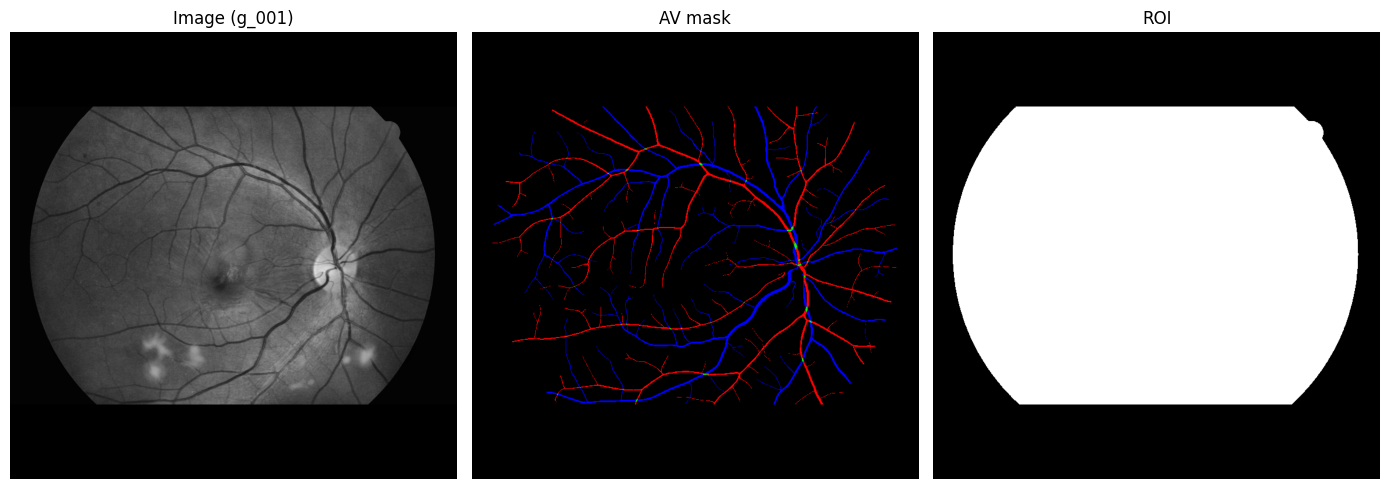

Image (768, 768, 3)  GT (768, 768)  ROI (768, 768)
GT classes present : [0, 1, 2, 3]


In [44]:
# =============================================================================
# Visual Verification
# =============================================================================

def class_to_rgb(mask):
    # Convert class mask back to RGB for visualization only.

    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    rgb[mask == 0] = [0, 0, 0]         # Background
    rgb[mask == 1] = [255, 0, 0]       # Artery
    rgb[mask == 2] = [0, 255, 0]       # Overlap
    rgb[mask == 3] = [0, 0, 255]       # Vein

    return rgb


_stem = ALL_STEMS[0]

_img = cv2.cvtColor(
    cv2.imread(os.path.join(PROCESSED_DIR, "images", f"{_stem}.png")),
    cv2.COLOR_BGR2RGB
)
_gt  = cv2.imread(os.path.join(PROCESSED_DIR, "av", f"{_stem}.png"), 0)
_roi = cv2.imread(os.path.join(PROCESSED_DIR, "masks", f"{_stem}.png"), 0)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, im, title in zip(
    axes,
    [_img, class_to_rgb(_gt), _roi],
    [f"Image ({_stem})", "AV mask", "ROI"]
):
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Image {_img.shape}  GT {_gt.shape}  ROI {_roi.shape}")
print(f"GT classes present : {sorted(np.unique(_gt).tolist())}")

---

# Cross-Validation Protocol

This revision replaces the single 34 / 8 / 8 split with a **frame-level
5-fold cross-validation** over 42 frames, with 8 frames held out entirely.

## Why

The previous protocol produced one estimate from 8 validation frames. Its
empirical noise floor was around **±0.02 Dice** — wider than nearly every
effect the notebook was trying to measure, including the reported test-time
augmentation gain of +0.016. Under those conditions neither checkpoint
selection nor ablation comparison is sound.

## What changed

| Component | Before | Now |
|---|---|---|
| Encoder | scratch AttentionUNet, 32.8M random | ImageNet ResNet34 + same attention decoder, 25.0M (21.3M pretrained) |
| Encoder LR | same as decoder | `ENCODER_LR_SCALE` = 0.1 |
| Input normalization | `/255` only | ImageNet mean/std, applied **inside** the model |
| TTA scoring | whole-frame forward pass | tiled, identical path to validation |
| Split | single 34/8/8 | 5-fold over 42, 8 held out |
| Split level | frames (implicit) | frames, with explicit leak assertions |
| Validation scoring | whole 768 frames | tiled 256 window, stride 128, logits averaged |
| Checkpoint weights | raw | EMA (decay 0.999) |
| LR schedule | cosine **warm restarts**, T_0 = 20 | plain cosine decay |
| Weight decay | 1e-4 | 1e-2 |
| clDice start | epoch 10, weight 0.30 | epoch 0, ramp 15, weight 0.10 |
| Early stopping | 25 | 15 |
| Reported metric | single number | mean ± std across folds |

## Leak protection

Patches are cut with a 256 window at stride 128, so neighbouring patches share
half their pixels. Splitting *patches* would place the same pixels on both
sides of the boundary. All splitting therefore happens on frame stems, before
any patch is written, and `assert` statements in the fold-assignment cell
verify that train, validation and test frame sets are pairwise disjoint and
that every cross-validation frame is validated exactly once. Those assertions
are load-bearing; do not relax them.

## Encoder

`ENCODER` switches between `"scratch"` (the original network, unchanged) and
`"resnet34"`. With roughly 34 training frames, initialising 32.8M parameters
from random is the dominant source of overfitting; a pretrained encoder is
normally the largest single gain available at this data scale. The scratch
model is kept intact so the comparison is a one-line ablation.

The decoder is unchanged in both cases — same attention gates, same
`DoubleConv` blocks, same kernel schedule — so the comparison isolates the
encoder. ResNet34 downsamples five times rather than four, so the decoder gains
a fifth upsample with no skip connection at full resolution.

Normalization is a `register_buffer` inside the model rather than a Dataset
transform, so training, tiled inference and TTA cannot diverge on it.
Encoder BatchNorm is frozen by default (`FREEZE_ENCODER_BN`): at batch size 8
on ~600 distinct patches, letting ImageNet running statistics drift is pure
variance.

**First run needs internet.** torchvision downloads the ImageNet weights once
and caches them under `~/.cache/torch`.

## Reading the result

`cv_results.json` records the configuration alongside the per-fold scores.
Keep one file per configuration. A change counts as real only when the
difference in mean Dice exceeds `SIGNIFICANCE_SIGMA` times the across-fold
standard deviation.

**Expect the headline number to fall relative to the old run.** The previous
0.6252 was a single favourable draw selected at epoch 8 on 8 frames. A
cross-validated mean is a different and more honest quantity; it is not
directly comparable to the old figure.

---

In [10]:
# =============================================================================
# Fold Assignment
# =============================================================================
#
# Split at FRAME level. Patches overlap by 50% (stride 128, window 256), so a
# patch-level split leaks pixels across the boundary and inflates validation.

from sklearn.model_selection import KFold

_rng = np.random.RandomState(SEED)
_perm = _rng.permutation(len(ALL_STEMS))

TEST_STEMS = sorted(ALL_STEMS[i] for i in _perm[:TEST_SIZE])
CV_STEMS   = sorted(ALL_STEMS[i] for i in _perm[TEST_SIZE:])

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

FOLDS = []

for tr_idx, va_idx in kf.split(CV_STEMS):

    tr = sorted(CV_STEMS[i] for i in tr_idx)
    va = sorted(CV_STEMS[i] for i in va_idx)

    FOLDS.append((tr, va))

# ---- leak assertions: these must never be relaxed ----

for f, (tr, va) in enumerate(FOLDS):

    assert not (set(tr) & set(va)), f"fold {f}: train/val frame overlap"
    assert not (set(tr) & set(TEST_STEMS)), f"fold {f}: train/test frame overlap"
    assert not (set(va) & set(TEST_STEMS)), f"fold {f}: val/test frame overlap"
    assert set(tr) | set(va) == set(CV_STEMS), f"fold {f}: frames lost"

assert not (set(CV_STEMS) & set(TEST_STEMS)), "cv/test frame overlap"

# Every CV frame is used for validation exactly once
_va_all = [x for _, va in FOLDS for x in va]
assert sorted(_va_all) == sorted(CV_STEMS), "fold coverage broken"
assert len(_va_all) == len(set(_va_all)), "frame validated twice"

# Persist so folds survive a kernel restart
with open("folds.json", "w") as fh:
    json.dump({"test": TEST_STEMS,
               "folds": [{"train": tr, "val": va} for tr, va in FOLDS]},
              fh, indent=2)

print("=" * 62)
print(f"Held-out test frames : {len(TEST_STEMS)}")
print(f"Cross-validated      : {len(CV_STEMS)} frames, {N_FOLDS} folds")
for f, (tr, va) in enumerate(FOLDS):
    print(f"  fold {f} : train {len(tr):>3d}  val {len(va):>3d}")
print("\nAll leak assertions passed. Splits written to folds.json")
print("=" * 62)

Held-out test frames : 8
Cross-validated      : 42 frames, 5 folds
  fold 0 : train  33  val   9
  fold 1 : train  33  val   9
  fold 2 : train  34  val   8
  fold 3 : train  34  val   8
  fold 4 : train  34  val   8

All leak assertions passed. Splits written to folds.json


In [11]:
def _rot(deg):
    return A.Rotate(limit=(deg, deg), border_mode=cv2.BORDER_CONSTANT,
                    interpolation=cv2.INTER_LINEAR,
                    mask_interpolation=cv2.INTER_NEAREST,
                    fill=0, fill_mask=0, p=1)

augmentations = {
    "hflip":        A.HorizontalFlip(p=1),
    "vflip":        A.VerticalFlip(p=1),
    "hvflip":       A.Compose([A.HorizontalFlip(p=1), A.VerticalFlip(p=1)]),
    "rot_p15":      _rot(15),
    "rot_m15":      _rot(-15),
    "rot_p25":      _rot(25),
    "rot_m25":      _rot(-25),
    "rot_p30":      _rot(30),
    "rot_m30":      _rot(-30),
    "hflip_rot20":  A.Compose([A.HorizontalFlip(p=1), _rot(20)]),
    "vflip_rot_m20":A.Compose([A.VerticalFlip(p=1), _rot(-20)]),

    "affine":       A.Affine(scale=(0.8, 1.15), translate_percent=(-0.05, 0.05),
                             shear=(-8, 8), interpolation=cv2.INTER_LINEAR,
                             mask_interpolation=cv2.INTER_NEAREST,
                             border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0, p=1),
    "elastic":      A.ElasticTransform(alpha=40, sigma=6,
                                       interpolation=cv2.INTER_LINEAR,
                                       mask_interpolation=cv2.INTER_NEAREST,
                                       border_mode=cv2.BORDER_CONSTANT,
                                       fill=0, fill_mask=0, p=1),

    "brightness":   A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1),
    "gamma":        A.RandomGamma(gamma_limit=(80, 120), p=1),
    "gaussian_blur":A.GaussianBlur(blur_limit=(3, 5), p=1),
    "gaussian_noise":A.GaussNoise(std_range=(0.02, 0.08), mean_range=(0.0, 0.0),
                                  per_channel=False, p=1),
}

# Register ROI as an additional mask target
augmentations = {
    k: A.Compose(
        v.transforms if isinstance(v, A.Compose) else [v],
        additional_targets={"roi": "mask"}
    )
    for k, v in augmentations.items()
}

In [12]:
# =============================================================================
# Per-Fold Dataset Construction
# =============================================================================
#
# Augmentation runs on the full 768x768 frame, BEFORE patching.
#
# Cutting patches first and then rotating them on a 256x256 canvas with
# BORDER_CONSTANT fill turns roughly a quarter of a 30-degree-rotated patch
# into synthetic black wedges that never occur at inference time, and 11 of the
# 18 variants are geometric. Augmenting the frame pushes those wedges to the
# frame corners, which already lie outside the retinal ROI. The ROI mask is
# warped with the frame, so wedge pixels get roi = 0 and the existing
# MIN_ROI_FRACTION criterion discards them with no extra logic.

INTENSITY_AUGS = {
    "brightness",
    "gamma",
    "gaussian_blur",
    "gaussian_noise"
}


def frame_variants(image, gt, roi):
    """
    Yield (name, image, gt, roi): the original frame plus every augmentation.
    Intensity augmentations leave the masks untouched.
    """

    yield "orig", image, gt, roi

    for aug_name, aug in augmentations.items():

        if aug_name in INTENSITY_AUGS:

            out = aug(image=image)

            yield aug_name, out["image"], gt, roi

        else:

            out = aug(image=image, mask=gt, roi=roi)

            yield aug_name, out["image"], out["mask"], out["roi"]


def write_patches(image, gt, roi, base, out_dir, rng, stats):
    """
    Cut the patch grid out of one frame, write patches passing the filter.
    """

    for y in range(0, IMAGE_SIZE - PATCH_SIZE + 1, PATCH_STRIDE):
        for x in range(0, IMAGE_SIZE - PATCH_SIZE + 1, PATCH_STRIDE):

            stats["examined"] += 1

            gt_patch  = gt[y:y + PATCH_SIZE, x:x + PATCH_SIZE]
            roi_patch = roi[y:y + PATCH_SIZE, x:x + PATCH_SIZE]

            if ENABLE_VESSEL_PATCHING:

                vessel_fraction = (gt_patch > 0).mean()
                roi_fraction    = (roi_patch > 0).mean()

                vessel_rich = (
                    vessel_fraction >= MIN_VESSEL_FRACTION
                    and roi_fraction >= MIN_ROI_FRACTION
                )

                if not vessel_rich:

                    if rng.random() >= BACKGROUND_KEEP_RATIO:
                        continue

                    stats["background"] += 1

            name = f"{base}_y{y}_x{x}.png"

            cv2.imwrite(
                os.path.join(out_dir, "images", name),
                cv2.cvtColor(image[y:y + PATCH_SIZE, x:x + PATCH_SIZE],
                             cv2.COLOR_RGB2BGR)
            )
            cv2.imwrite(os.path.join(out_dir, "av", name), gt_patch)
            cv2.imwrite(os.path.join(out_dir, "masks", name), roi_patch)

            stats["kept"] += 1


def build_fold_dataset(train_stems, verbose=True):
    """
    Wipe FOLD_DIR and rebuild the training patch set from the given frames.
    Validation frames are never patched -- they are scored whole, by tiling.
    """

    for sub in ["images", "av", "masks"]:
        d = os.path.join(FOLD_DIR, "train", sub)
        if os.path.exists(d):
            shutil.rmtree(d)
        os.makedirs(d, exist_ok=True)

    out_dir = os.path.join(FOLD_DIR, "train")

    rng = random.Random(SEED)
    stats = {"examined": 0, "kept": 0, "background": 0}

    it = tqdm(train_stems, desc="augment + patch") if verbose else train_stems

    for stem in it:

        image = cv2.cvtColor(
            cv2.imread(os.path.join(PROCESSED_DIR, "images", f"{stem}.png")),
            cv2.COLOR_BGR2RGB
        )
        gt  = cv2.imread(os.path.join(PROCESSED_DIR, "av", f"{stem}.png"), 0)
        roi = cv2.imread(os.path.join(PROCESSED_DIR, "masks", f"{stem}.png"), 0)

        for aug_name, ai, ag, ar in frame_variants(image, gt, roi):

            write_patches(ai, ag, ar, f"{stem}_{aug_name}",
                          out_dir, rng, stats)

    if verbose:
        n_var = 1 + len(augmentations)
        print(f"\nFrames   : {len(train_stems)} x {n_var} variants")
        print(f"Examined : {stats['examined']}")
        print(f"Kept     : {stats['kept']} "
              f"({stats['kept'] - stats['background']} vessel-rich, "
              f"{stats['background']} background)")

    return stats

In [42]:
# =============================================================================
# Datasets
# =============================================================================

class PatchDataset(Dataset):
    """Training patches, read from the per-fold FOLD_DIR tree."""

    def __init__(self, image_dir, mask_dir, compute_weights=False):

        self.images = sorted(glob(os.path.join(image_dir, "*")))
        self.masks  = sorted(glob(os.path.join(mask_dir, "*")))

        assert len(self.images) == len(self.masks), \
            "Mismatch between images and masks."

        self.weights = None

        if compute_weights:

            w = []

            for m in tqdm(self.masks, desc="sample weights", leave=False):

                gt = cv2.imread(m, cv2.IMREAD_GRAYSCALE)

                vessel  = (gt > 0).mean()
                overlap = (gt == 2).mean()

                w.append(
                    max(vessel, WEIGHT_FLOOR) ** 0.5
                    + OVERLAP_BOOST * (overlap ** 0.5)
                )

            self.weights = np.array(w, dtype=np.float64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = cv2.cvtColor(cv2.imread(self.images[idx]), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(self.masks[idx], cv2.IMREAD_GRAYSCALE)

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        return torch.from_numpy(image).float(), torch.from_numpy(mask).long()


class FrameDataset(Dataset):
    """Whole 768x768 frames. Used for validation and test, never for training."""

    def __init__(self, stems):
        self.stems = list(stems)

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):

        stem = self.stems[idx]

        image = cv2.cvtColor(
            cv2.imread(os.path.join(PROCESSED_DIR, "images", f"{stem}.png")),
            cv2.COLOR_BGR2RGB
        )
        mask = cv2.imread(os.path.join(PROCESSED_DIR, "av", f"{stem}.png"), 0)

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        return torch.from_numpy(image).float(), torch.from_numpy(mask).long()

In [36]:
# Double Convolution Block

import math


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size=3):

        super().__init__()

        if kernel_size % 2 == 0:
            raise ValueError(
                f"kernel_size must be odd, got {kernel_size}. "
                "Even kernels cannot be symmetrically padded and will "
                "misalign the skip connections."
            )

        padding = kernel_size // 2

        groups = math.gcd(8, out_channels)

        self.kernel_size = kernel_size

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=padding,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=padding,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)


In [37]:
# Attention Gate

class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()


        groups = math.gcd(8, F_int)

        self.W_g = nn.Sequential(

            nn.Conv2d(
                F_g,
                F_int,
                kernel_size=1,
                bias=True
            ),

            nn.GroupNorm(
                groups,
                F_int
            )

        )

        self.W_x = nn.Sequential(

            nn.Conv2d(
                F_l,
                F_int,
                kernel_size=1,
                bias=True
            ),

            nn.GroupNorm(
                groups,
                F_int
            )

        )

        self.psi = nn.Sequential(

            nn.Conv2d(
                F_int,
                1,
                kernel_size=1,
                bias=True
            ),

            nn.Sigmoid()

        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)

        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        return x * psi

In [38]:
# Encoder Block

class EncoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size=3):

        super().__init__()

        self.conv = DoubleConv(in_channels, out_channels, kernel_size)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        skip = self.conv(x)

        pooled = self.pool(skip)

        return skip, pooled


In [39]:
# Decoder Block

class DecoderBlock(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels,
                 kernel_size=3):

        super().__init__()

        # Upsampling stays 2x2 stride 2 regardless of the conv kernel --
        # this is a resampling op, not a feature extractor.
        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.attention = AttentionBlock(
            F_g=out_channels,
            F_l=skip_channels,
            F_int=out_channels // 2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels,
            kernel_size
        )

    def forward(self, x, skip):

        x = self.up(x)

        skip = self.attention(x, skip)

        x = torch.cat([skip, x], dim=1)

        return self.conv(x)


In [40]:
# Attention U-Net with Deep Supervision

class AttentionUNet(nn.Module):

    def __init__(self, in_channels=3, num_classes=4, base_width=64,
                 kernel_size=3, kernel_depth=0):
        """
        base_width   : channels at the first encoder stage; every stage scales
                       from it. 64 reproduces the original network.
        kernel_size  : conv kernel for the shallow stages
        kernel_depth : how many encoder stages (from the top) use kernel_size.
                       Their mirrored decoder stages match. 0 = all 3x3.
        """

        super().__init__()

        # Per-stage kernel schedule: wide at full resolution, 3x3 deeper.
        k = [kernel_size if i < kernel_depth else 3 for i in range(4)]

        self.kernel_schedule = k

        w = base_width
        c1, c2, c3, c4 = w, w * 2, w * 4, w * 8
        cb = w * 16

        self.widths = [c1, c2, c3, c4, cb]

        # Encoder

        self.enc1 = EncoderBlock(in_channels, c1, k[0])
        self.enc2 = EncoderBlock(c1, c2, k[1])
        self.enc3 = EncoderBlock(c2, c3, k[2])
        self.enc4 = EncoderBlock(c3, c4, k[3])

        # Bottleneck -- always 3x3. It already has the largest receptive
        # field and by far the most parameters.

        self.bottleneck = DoubleConv(c4, cb, 3)

        # Decoder (mirrors the encoder schedule)

        self.dec4 = DecoderBlock(cb, c4, c4, k[3])
        self.dec3 = DecoderBlock(c4, c3, c3, k[2])
        self.dec2 = DecoderBlock(c3, c2, c2, k[1])
        self.dec1 = DecoderBlock(c2, c1, c1, k[0])

        # Main Output

        self.out = nn.Conv2d(c1, num_classes, kernel_size=1)

        # Deep Supervision Heads

        self.ds4 = nn.Conv2d(c4, num_classes, kernel_size=1)
        self.ds3 = nn.Conv2d(c3, num_classes, kernel_size=1)
        self.ds2 = nn.Conv2d(c2, num_classes, kernel_size=1)

        self.initialize_weights()

    def initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, nn.GroupNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):

        s1, p1 = self.enc1(x)
        s2, p2 = self.enc2(p1)
        s3, p3 = self.enc3(p2)
        s4, p4 = self.enc4(p3)

        b = self.bottleneck(p4)

        d4 = self.dec4(b, s4)
        d3 = self.dec3(d4, s3)
        d2 = self.dec2(d3, s2)
        d1 = self.dec1(d2, s1)

        out = self.out(d1)

        aux4 = self.ds4(d4)
        aux3 = self.ds3(d3)
        aux2 = self.ds2(d2)

        up = lambda t: F.interpolate(
            t, size=out.shape[2:], mode="bilinear", align_corners=False
        )

        return out, up(aux2), up(aux3), up(aux4)

In [19]:
# =============================================================================
# ResNet34 Encoder + Attention Decoder
# =============================================================================
#
# Encoder: torchvision ResNet34, ImageNet weights. No extra dependency.
# Decoder: the same attention gates, DoubleConv blocks and kernel schedule as
# the scratch model, so the comparison isolates the encoder.
#
# Feature map sizes (input H x W):
#
#   stem   conv1+bn+relu ->  64ch, H/2     skip
#   layer1 (after pool)  ->  64ch, H/4     skip
#   layer2               -> 128ch, H/8     skip
#   layer3               -> 256ch, H/16    skip
#   layer4               -> 512ch, H/32    bottleneck
#
# That is one downsample deeper than the scratch encoder, so the decoder needs
# a fifth upsample -- the last one has no skip to attend to, since ResNet
# produces no full-resolution feature map.

from torchvision.models import resnet34, ResNet34_Weights


class FinalUp(nn.Module):
    # Last upsample, H/2 -> H. No skip connection available at full resolution.

    def __init__(self, in_channels, out_channels, kernel_size=3):

        super().__init__()

        self.up = nn.ConvTranspose2d(in_channels, out_channels,
                                     kernel_size=2, stride=2)

        self.conv = DoubleConv(out_channels, out_channels, kernel_size)

    def forward(self, x):
        return self.conv(self.up(x))


class ResNetAttentionUNet(nn.Module):

    # ImageNet statistics. Applied inside the model rather than in the Dataset
    # so that every path -- training, tiled inference, TTA -- normalises
    # identically and none of them can be forgotten.
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    def __init__(self, num_classes=4, kernel_size=3, kernel_depth=0,
                 pretrained=True, freeze_bn=True):

        super().__init__()

        k = [kernel_size if i < kernel_depth else 3 for i in range(4)]

        self.kernel_schedule = k
        self.freeze_bn = freeze_bn

        weights = ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        net = resnet34(weights=weights)

        self.stem = nn.Sequential(net.conv1, net.bn1, net.relu)   #  64, H/2
        self.pool = net.maxpool
        self.layer1 = net.layer1                                   #  64, H/4
        self.layer2 = net.layer2                                   # 128, H/8
        self.layer3 = net.layer3                                   # 256, H/16
        self.layer4 = net.layer4                                   # 512, H/32

        self.encoder_modules = [self.stem, self.layer1, self.layer2,
                                self.layer3, self.layer4]

        # Decoder mirrors the kernel schedule: widest kernels nearest full
        # resolution, where thin-vessel context lives.
        self.dec4 = DecoderBlock(512, 256, 256, k[3])   # -> H/16
        self.dec3 = DecoderBlock(256, 128, 128, k[2])   # -> H/8
        self.dec2 = DecoderBlock(128,  64,  64, k[1])   # -> H/4
        self.dec1 = DecoderBlock(64,   64,  64, k[0])   # -> H/2

        self.final = FinalUp(64, 32, k[0])              # -> H

        self.out = nn.Conv2d(32, num_classes, kernel_size=1)

        self.ds4 = nn.Conv2d(256, num_classes, kernel_size=1)
        self.ds3 = nn.Conv2d(128, num_classes, kernel_size=1)
        self.ds2 = nn.Conv2d(64,  num_classes, kernel_size=1)

        self.register_buffer(
            "norm_mean",
            torch.tensor(self.IMAGENET_MEAN).view(1, 3, 1, 1)
        )
        self.register_buffer(
            "norm_std",
            torch.tensor(self.IMAGENET_STD).view(1, 3, 1, 1)
        )

        self._init_decoder()

    def _init_decoder(self):

        decoder = [self.dec4, self.dec3, self.dec2, self.dec1, self.final,
                   self.out, self.ds4, self.ds3, self.ds2]

        for block in decoder:
            for m in block.modules():

                if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                    nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                            nonlinearity="relu")
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)

                elif isinstance(m, nn.GroupNorm):
                    nn.init.ones_(m.weight)
                    nn.init.zeros_(m.bias)

    def train(self, mode=True):

        super().train(mode)

        if mode and self.freeze_bn:
            for block in self.encoder_modules:
                for m in block.modules():
                    if isinstance(m, nn.BatchNorm2d):
                        m.eval()

        return self

    def encoder_parameters(self):
        for block in self.encoder_modules:
            yield from block.parameters()

    def decoder_parameters(self):
        enc = {id(p) for p in self.encoder_parameters()}
        for p in self.parameters():
            if id(p) not in enc:
                yield p

    def forward(self, x):

        x = (x - self.norm_mean) / self.norm_std

        f1 = self.stem(x)                 #  64, H/2
        f2 = self.layer1(self.pool(f1))   #  64, H/4
        f3 = self.layer2(f2)              # 128, H/8
        f4 = self.layer3(f3)              # 256, H/16
        b  = self.layer4(f4)              # 512, H/32

        d4 = self.dec4(b,  f4)
        d3 = self.dec3(d4, f3)
        d2 = self.dec2(d3, f2)
        d1 = self.dec1(d2, f1)

        out = self.out(self.final(d1))

        aux4 = self.ds4(d4)
        aux3 = self.ds3(d3)
        aux2 = self.ds2(d2)

        up = lambda t: F.interpolate(t, size=out.shape[2:],
                                     mode="bilinear", align_corners=False)

        return out, up(aux2), up(aux3), up(aux4)


def build_model():
    # Single construction point. Every cell that needs a model calls this, so
    # the encoder switch cannot be applied inconsistently.

    if ENCODER == "resnet34":

        return ResNetAttentionUNet(
            num_classes=NUM_CLASSES,
            kernel_size=KERNEL_SIZE,
            kernel_depth=KERNEL_DEPTH,
            pretrained=True,
            freeze_bn=FREEZE_ENCODER_BN
        ).to(DEVICE)

    return AttentionUNet(
        in_channels=3,
        num_classes=NUM_CLASSES,
        base_width=BASE_WIDTH,
        kernel_size=KERNEL_SIZE,
        kernel_depth=KERNEL_DEPTH
    ).to(DEVICE)


def build_optimizer(model):
    # Discriminative learning rates: pretrained encoder moves slowly, random
    # decoder moves at full rate.

    if ENCODER == "resnet34":

        return torch.optim.AdamW(
            [
                {"params": list(model.encoder_parameters()),
                 "lr": LR * ENCODER_LR_SCALE},
                {"params": list(model.decoder_parameters()),
                 "lr": LR},
            ],
            weight_decay=WEIGHT_DECAY
        )

    return torch.optim.AdamW(model.parameters(), lr=LR,
                             weight_decay=WEIGHT_DECAY)

In [50]:
_m = build_model()
_n = sum(p.numel() for p in _m.parameters())
_t = sum(p.numel() for p in _m.parameters() if p.requires_grad)

_ref = AttentionUNet(3, NUM_CLASSES, 64, 3, 0)
_nref = sum(p.numel() for p in _ref.parameters())

print(f"Encoder                      : {ENCODER}")
print(f"Kernel schedule              : {_m.kernel_schedule}")
print(f"Parameters                   : {_n:,}  ({_t:,} trainable)")
print(f"scratch width-64 all-3x3 ref : {_nref:,}")
print(f"Ratio                        : {_n / _nref:.3f}x")

if ENCODER == "resnet34":
    _e = sum(p.numel() for p in _m.encoder_parameters())
    print(f"  encoder (pretrained)       : {_e:,} @ lr x{ENCODER_LR_SCALE}")
    print(f"  decoder (random init)      : {_n - _e:,} @ lr x1")

with torch.no_grad():
    _m.eval()
    _o = _m(torch.rand(1, 3, PATCH_SIZE, PATCH_SIZE, device=DEVICE))

assert len(_o) == 4, "model must return (main, aux2, aux3, aux4)"

for _i, _x in enumerate(_o):
    assert _x.shape[-2:] == (PATCH_SIZE, PATCH_SIZE), \
        f"output {_i} has shape {tuple(_x.shape)}, expected {PATCH_SIZE}"

print(f"Shape check                  : OK, 4 heads at {PATCH_SIZE}x{PATCH_SIZE}")

del _m, _ref, _o

Encoder                      : resnet34
Kernel schedule              : [5, 5, 3, 3]
Parameters                   : 24,971,380  (24,971,380 trainable)
scratch width-64 all-3x3 ref : 31,392,948
Ratio                        : 0.795x
  encoder (pretrained)       : 21,284,672 @ lr x0.1
  decoder (random init)      : 3,686,708 @ lr x1
Shape check                  : OK, 4 heads at 256x256


In [ ]:
# Multi-Class Focal Tversky Loss

class FocalTverskyLoss(nn.Module):

    def __init__(
        self,
        alpha=ALPHA,
        beta=BETA,
        gamma=GAMMA,
        smooth=1e-6,
        num_classes=NUM_CLASSES
    ):
        super().__init__()

        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth
        self.num_classes = num_classes

    def forward(self, logits, targets):

        # Convert logits to probabilities
        probs = torch.softmax(logits, dim=1)

        # Convert targets to one-hot encoding
        targets_onehot = F.one_hot(
            targets,
            self.num_classes
        ).permute(0, 3, 1, 2).float()

        # Flatten spatial dimensions
        probs = probs.flatten(2)
        targets_onehot = targets_onehot.flatten(2)

        # Compute Tversky statistics
        TP = (probs * targets_onehot).sum(dim=2)
        FP = (probs * (1 - targets_onehot)).sum(dim=2)
        FN = ((1 - probs) * targets_onehot).sum(dim=2)

        tversky = (
            TP + self.smooth
        ) / (
            TP +
            self.alpha * FP +
            self.beta * FN +
            self.smooth
        )

        focal_tversky = (1.0 - tversky) ** self.gamma

        return focal_tversky.mean()

In [21]:
 # Soft Skeletonization
 
def soft_erode(img):

    if img.dim() == 4:

        p1 = -F.max_pool2d(-img, (3,1), stride=1, padding=(1,0))

        p2 = -F.max_pool2d(-img, (1,3), stride=1, padding=(0,1))

        return torch.min(p1, p2)

    raise ValueError("Expected 4D tensor")


def soft_dilate(img):

    return F.max_pool2d(
        img,
        kernel_size=3,
        stride=1,
        padding=1
    )


def soft_open(img):

    return soft_dilate(
        soft_erode(img)
    )


def soft_skeletonize(img, iterations=CLDICE_ITERATIONS):

    img1 = soft_open(img)

    skeleton = F.relu(img - img1)

    for _ in range(iterations):

        img = soft_erode(img)

        opened = soft_open(img)

        delta = F.relu(img-opened)

        skeleton = skeleton + F.relu(delta - skeleton*delta)

    return skeleton

In [22]:
# Multi-Class CLDice Loss

class CLDiceLoss(nn.Module):

    def __init__(
        self,
        num_classes=NUM_CLASSES,
        iterations=CLDICE_ITERATIONS,
        smooth=1e-6
    ):

        super().__init__()

        self.num_classes = num_classes
        self.iterations = iterations
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.softmax(logits, dim=1)
        
        # Ignore background channel
        probs = probs[:, 1:, :, :]

        targets = F.one_hot(
            targets,
            self.num_classes
        ).permute(0,3,1,2).float()

        targets = targets[:, 1:, :, :]
        
        skel_pred = soft_skeletonize(
            probs,
            self.iterations
        )

        skel_gt = soft_skeletonize(
            targets,
            self.iterations
        )

        tprec = (

            (skel_pred * targets).sum((2,3))

            + self.smooth

        ) / (

            skel_pred.sum((2,3))

            + self.smooth

        )

        tsens = (

            (skel_gt * probs).sum((2,3))

            + self.smooth

        ) / (

            skel_gt.sum((2,3))

            + self.smooth

        )

        cldice = (

            2*tprec*tsens

        ) / (

            tprec + tsens + self.smooth

        )

        return 1 - cldice.mean()

In [23]:
focal_tversky_loss = FocalTverskyLoss(
    alpha=ALPHA,
    beta=BETA,
    gamma=GAMMA,
    num_classes=NUM_CLASSES
)

cldice_loss = CLDiceLoss(
    num_classes=NUM_CLASSES,
    iterations=CLDICE_ITERATIONS
)

NameError: name 'FocalTverskyLoss' is not defined

In [24]:
# Hybrid Loss with ramped clDice curriculum
# Weights, start epoch and ramp length come from the configuration cell.


def cldice_weight_at(epoch):
    """
    Linear ramp of the clDice weight.

    Returns 0 before CLDICE_START_EPOCH, then ramps to CLDICE_WEIGHT over
    CLDICE_RAMP_EPOCHS epochs. A hard switch (the previous behaviour) is
    recovered by setting CLDICE_RAMP_EPOCHS = 1.

    Soft skeletons of an under-converged prediction carry little signal,
    which is why the term is faded in rather than dropped in at full weight.
    """

    if epoch < CLDICE_START_EPOCH:
        return 0.0

    progress = (epoch - CLDICE_START_EPOCH + 1) / max(1, CLDICE_RAMP_EPOCHS)

    return CLDICE_WEIGHT * min(1.0, progress)


def hybrid_loss(outputs, targets, epoch=0):

    main, aux2, aux3, aux4 = outputs

    ft_main = focal_tversky_loss(main, targets)

    w_cl = cldice_weight_at(epoch)

    if w_cl > 0.0:

        # clDice is numerically fragile under fp16: the soft-skeleton
        # iterations compound small errors, so force fp32.
        with torch.amp.autocast("cuda", enabled=False):
            cl_main = cldice_loss(main.float(), targets)

        # Complementary weighting keeps the main term's scale constant
        # across the ramp, so val loss stays roughly comparable.
        main_loss = (1.0 - w_cl) * ft_main + w_cl * cl_main

    else:
        main_loss = ft_main

    # Deep supervision heads stay on Focal Tversky only. Topology loss on
    # 2x/4x/8x downsampled logits is meaningless -- thin vessels do not
    # survive the downsampling.
    aux2_loss = focal_tversky_loss(aux2, targets)
    aux3_loss = focal_tversky_loss(aux3, targets)
    aux4_loss = focal_tversky_loss(aux4, targets)

    return main_loss + 0.40 * aux2_loss + 0.25 * aux3_loss + 0.15 * aux4_loss


print("clDice ramp schedule:")
for _e in range(0, CLDICE_START_EPOCH + CLDICE_RAMP_EPOCHS + 3):
    print(f"  epoch {_e:>3d} : clDice weight = {cldice_weight_at(_e):.3f}")


clDice ramp schedule:
  epoch   0 : clDice weight = 0.007
  epoch   1 : clDice weight = 0.013
  epoch   2 : clDice weight = 0.020
  epoch   3 : clDice weight = 0.027
  epoch   4 : clDice weight = 0.033
  epoch   5 : clDice weight = 0.040
  epoch   6 : clDice weight = 0.047
  epoch   7 : clDice weight = 0.053
  epoch   8 : clDice weight = 0.060
  epoch   9 : clDice weight = 0.067
  epoch  10 : clDice weight = 0.073
  epoch  11 : clDice weight = 0.080
  epoch  12 : clDice weight = 0.087
  epoch  13 : clDice weight = 0.093
  epoch  14 : clDice weight = 0.100
  epoch  15 : clDice weight = 0.100
  epoch  16 : clDice weight = 0.100
  epoch  17 : clDice weight = 0.100


In [25]:
@torch.no_grad()
def dice_score(
    preds,
    targets,
    num_classes=NUM_CLASSES,
    ignore_background=True,
    smooth=1e-6
):

    preds = torch.argmax(preds, dim=1)

    dice_scores = []

    start_class = 1 if ignore_background else 0

    for cls in range(start_class, num_classes):

        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        # A class absent from both prediction and target is undefined, not
        # perfect. Scoring it 1.0 inflates the mean, which matters most for
        # the rare overlap class.
        if target_cls.sum() == 0 and pred_cls.sum() == 0:
            dice_scores.append(
                torch.tensor(float("nan"), device=preds.device)
            )
            continue

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        dice = (2.0 * intersection + smooth) / (union + smooth)

        dice_scores.append(dice)

    dice_scores = torch.stack(dice_scores)

    mean_dice = torch.nanmean(dice_scores).item()

    return mean_dice, dice_scores.cpu().tolist()

In [26]:
@torch.no_grad()
def iou_score(
    preds,
    targets,
    num_classes=NUM_CLASSES,
    ignore_background=True,
    smooth=1e-6
):

    preds = torch.argmax(preds, dim=1)

    iou_scores = []

    start_class = 1 if ignore_background else 0

    for cls in range(start_class, num_classes):

        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        # A class absent from both prediction and target is undefined, not
        # perfect. Scoring it 1.0 inflates the mean, which matters most for
        # the rare overlap class.
        if target_cls.sum() == 0 and pred_cls.sum() == 0:
            iou_scores.append(
                torch.tensor(float("nan"), device=preds.device)
            )
            continue

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum() - intersection

        iou = (intersection + smooth) / (union + smooth)

        iou_scores.append(iou)

    iou_scores = torch.stack(iou_scores)

    mean_iou = torch.nanmean(iou_scores).item()

    return mean_iou, iou_scores.cpu().tolist()

In [27]:
# Precision, Recall, F1 and Accuracy

from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score
)

CLASS_NAMES = [
    "Background",
    "Artery",
    "Overlap",
    "Vein"
]


@torch.no_grad()
def classification_metrics(preds, targets):

    preds = preds.detach()
    preds = torch.argmax(preds, dim=1)
    preds = preds.cpu().numpy().ravel()

    targets = targets.detach().cpu().numpy().ravel()

    precision, recall, f1, _ = precision_recall_fscore_support(
        targets,
        preds,
        labels=[0, 1, 2, 3],
        average=None,
        zero_division=0
    )

    accuracy = accuracy_score(
        targets,
        preds
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [28]:
# =============================================================================
# Exponential Moving Average of Weights
# =============================================================================
#
# Averaging the trajectory is a cheap variance reduction. With a validation set
# this small, a single-epoch checkpoint is a noisy draw; the EMA is not.

import copy
from contextlib import contextmanager


class EMA:

    def __init__(self, model, decay=EMA_DECAY):

        self.decay = decay

        self.shadow = {
            k: v.detach().clone().float()
            for k, v in model.state_dict().items()
        }

    @torch.no_grad()
    def update(self, model):

        for k, v in model.state_dict().items():

            if v.dtype.is_floating_point:
                self.shadow[k].mul_(self.decay).add_(
                    v.detach().float(), alpha=1.0 - self.decay
                )
            else:
                self.shadow[k] = v.detach().clone().float()


@contextmanager
def ema_weights(model, ema):
    """Temporarily swap the EMA weights into the model."""

    backup = copy.deepcopy(model.state_dict())

    model.load_state_dict(
        {k: ema.shadow[k].to(dtype=backup[k].dtype) for k in backup}
    )

    try:
        yield model
    finally:
        model.load_state_dict(backup)

In [29]:
# =============================================================================
# Tiled Inference and Frame-level Evaluation
# =============================================================================
#
# The network is trained on 256x256 patches. Scoring it on whole 768x768 frames
# measured two things at once -- model quality and a resolution mismatch.
# Sliding a PATCH_SIZE window and averaging the overlapping logits keeps the
# input distribution identical to training while the metric is still computed
# on the full frame.

def _tile_starts(length, patch, stride):

    starts = list(range(0, length - patch + 1, stride))

    if starts[-1] != length - patch:
        starts.append(length - patch)

    return starts


@torch.no_grad()
def predict_tiled(model, x, patch=None, stride=None, tile_batch=8,
                  use_amp=True):
    """
    Tiled forward pass over a batch of whole frames.

    x : (N, C, H, W) float tensor
    returns (N, NUM_CLASSES, H, W) averaged logits on DEVICE

    Shared by evaluate_frames and predict_tta, so validation, test and TTA all
    score through an identical input pipeline.
    """

    patch  = patch  or PATCH_SIZE
    stride = stride or TILE_STRIDE

    x = x.to(DEVICE, non_blocking=True)

    N, _, H, W = x.shape

    assert H >= patch and W >= patch, \
        f"frame {H}x{W} is smaller than the {patch} tile"

    logits = torch.zeros(N, NUM_CLASSES, H, W, device=DEVICE)
    counts = torch.zeros(1, 1, H, W, device=DEVICE)

    coords = [(y, x0)
              for y in _tile_starts(H, patch, stride)
              for x0 in _tile_starts(W, patch, stride)]

    amp_on = use_amp and DEVICE.type == "cuda"

    for i in range(0, len(coords), tile_batch):

        chunk = coords[i:i + tile_batch]

        # (len(chunk) * N, C, patch, patch)
        tiles = torch.cat([
            x[:, :, y:y + patch, x0:x0 + patch] for y, x0 in chunk
        ], dim=0)

        with torch.amp.autocast("cuda", enabled=amp_on):
            out = model(tiles)[0].float()

        for j, (y, x0) in enumerate(chunk):
            logits[:, :, y:y + patch, x0:x0 + patch] += out[j * N:(j + 1) * N]
            counts[:, :, y:y + patch, x0:x0 + patch] += 1

    return logits / counts


@torch.no_grad()
def predict_frame(model, image, **kwargs):
    """Convenience wrapper: (3, H, W) in, (NUM_CLASSES, H, W) out."""

    return predict_tiled(model, image.unsqueeze(0), **kwargs)[0]


@torch.no_grad()
def evaluate_frames(model, stems, desc="eval"):
    """
    Tiled prediction on whole frames. Dice and IoU are computed per frame and
    averaged across frames, so every frame carries equal weight regardless of
    how much vessel it contains.
    """

    model.eval()

    dice_values, iou_values = [], []
    acc_values = []
    prec = np.zeros(NUM_CLASSES)
    rec  = np.zeros(NUM_CLASSES)
    f1   = np.zeros(NUM_CLASSES)

    ds = FrameDataset(stems)

    for i in tqdm(range(len(ds)), desc=desc, leave=False):

        image, mask = ds[i]

        logits = predict_frame(model, image).unsqueeze(0)
        target = mask.unsqueeze(0).to(DEVICE)

        d, _ = dice_score(logits, target)
        u, _ = iou_score(logits, target)

        m = classification_metrics(logits, target)

        dice_values.append(d)
        iou_values.append(u)
        acc_values.append(m["accuracy"])

        prec += m["precision"]
        rec  += m["recall"]
        f1   += m["f1"]

    n = len(ds)

    return {
        "dice": float(np.nanmean(dice_values)),
        "iou":  float(np.nanmean(iou_values)),
        "accuracy": float(np.mean(acc_values)),
        "precision": prec / n,
        "recall": rec / n,
        "f1": f1 / n,
    }

In [30]:
# Train One Epoch

def train_one_epoch(model, loader, optimizer, scaler, device, epoch=0, ema=None):

    model.train()

    running_loss = 0.0

    # Collected rather than summed: a batch where a class is absent from both
    # prediction and target yields nan for that class, which must not poison
    # the epoch mean.
    dice_values = []
    iou_values = []

    progress = tqdm(loader, leave=False)

    for images, masks in progress:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):

            outputs = model(images)

            loss = hybrid_loss(outputs, masks, epoch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)

        main_output = outputs[0]

        dice, _ = dice_score(main_output, masks)
        iou, _ = iou_score(main_output, masks)

        running_loss += float(loss.detach())

        dice_values.append(dice)
        iou_values.append(iou)

        progress.set_postfix(
            Loss=f"{float(loss.detach()):.4f}",
            Dice=f"{dice:.4f}",
            IoU=f"{iou:.4f}"
        )

    return (
        running_loss / len(loader),
        float(np.nanmean(dice_values)),
        float(np.nanmean(iou_values))
    )

In [31]:
# =============================================================================
# Single-Fold Training Run
# =============================================================================

def run_fold(fold, train_stems, val_stems):

    print("=" * 62)
    print(f"FOLD {fold}  |  train {len(train_stems)} frames, "
          f"val {len(val_stems)} frames")
    print("=" * 62)

    assert not (set(train_stems) & set(val_stems)), "leak inside run_fold"

    # ---- data ----

    build_fold_dataset(train_stems)

    train_dataset = PatchDataset(
        os.path.join(FOLD_DIR, "train/images"),
        os.path.join(FOLD_DIR, "train/av"),
        compute_weights=True
    )

    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(train_dataset.weights).double(),
        num_samples=len(train_dataset),
        replacement=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=True
    )

    # ---- model ----

    model = build_model()

    optimizer = build_optimizer(model)

    # Plain cosine decay. The previous warm-restart schedule (T_0 = 20) fired a
    # restart at epoch 21 that spiked training loss from 0.331 to 0.406 and
    # burned twelve epochs of early-stopping patience for nothing.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,
        eta_min=1e-6
    )

    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

    ema = EMA(model, EMA_DECAY)

    # ---- loop ----

    best = {"dice": -1.0, "epoch": -1}
    since_improved = 0

    history = {"train_loss": [], "train_dice": [], "val_dice": [], "val_iou": []}

    for epoch in range(EPOCHS):

        w_cl = cldice_weight_at(epoch)

        print(f"\nFold {fold} | Epoch [{epoch + 1}/{EPOCHS}] "
              f"(clDice weight {w_cl:.3f}, "
              f"lr {scheduler.get_last_lr()[-1]:.2e})")

        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, optimizer, scaler, DEVICE, epoch, ema
        )

        with ema_weights(model, ema):
            val = evaluate_frames(model, val_stems, desc=f"fold {fold} val")

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val["dice"])
        history["val_iou"].append(val["iou"])

        print(f"  train  loss {train_loss:.4f} | dice {train_dice:.4f}")
        print(f"  val    dice {val['dice']:.4f} | iou {val['iou']:.4f} "
              f"| acc {val['accuracy']:.4f}")
        print("         " + "  ".join(
            f"{c[:4]} F1={val['f1'][i]:.3f}" for i, c in enumerate(CLASS_NAMES)
        ))

        if val["dice"] > best["dice"]:

            best = {"dice": val["dice"], "iou": val["iou"], "epoch": epoch,
                    "accuracy": val["accuracy"],
                    "precision": val["precision"], "recall": val["recall"],
                    "f1": val["f1"]}

            since_improved = 0

            torch.save(
                {
                    "fold": fold,
                    "epoch": epoch,
                    "ema_state_dict": {k: v.clone() for k, v in ema.shadow.items()},
                    "model_state_dict": model.state_dict(),
                    "val_dice": val["dice"],
                    "train_stems": train_stems,
                    "val_stems": val_stems,
                },
                fold_checkpoint(fold)
            )

            print("  -> best, checkpoint saved")

        else:

            since_improved += 1
            print(f"  early stopping {since_improved}/{EARLY_STOPPING_PATIENCE}")

            if since_improved >= EARLY_STOPPING_PATIENCE:
                print("  -> early stopping")
                break

    print(f"\nFold {fold} best: dice {best['dice']:.4f} at epoch {best['epoch']}")

    return best, history

In [32]:
# =============================================================================
# Run Cross-Validation
# =============================================================================

import time

_t0 = time.time()

fold_results = []
fold_histories = []

for fold, (tr, va) in enumerate(FOLDS):

    best, hist = run_fold(fold, tr, va)

    fold_results.append(best)
    fold_histories.append(hist)

print(f"\nTotal CV time: {(time.time() - _t0) / 3600:.2f} h")

FOLD 0  |  train 33 frames, val 9 frames


NameError: name 'build_fold_dataset' is not defined

In [34]:
# =============================================================================
# Cross-Validation Summary
# =============================================================================
#
# The number that matters is mean +/- std across folds. A single fold's score
# is one draw from a distribution roughly as wide as most of the effects being
# chased, which is exactly why the old single-split protocol could not resolve
# them.

def summarise(results, label):

    dice = np.array([r["dice"] for r in results])
    iou  = np.array([r["iou"] for r in results])
    acc  = np.array([r["accuracy"] for r in results])
    f1   = np.stack([r["f1"] for r in results])

    print("=" * 62)
    print(label)
    print("=" * 62)
    print(f"{'Dice':<12}{dice.mean():.4f} +/- {dice.std():.4f}"
          f"   folds: {np.round(dice, 4).tolist()}")
    print(f"{'IoU':<12}{iou.mean():.4f} +/- {iou.std():.4f}")
    print(f"{'Accuracy':<12}{acc.mean():.4f} +/- {acc.std():.4f}")
    print("-" * 62)
    print("Per-class F1")
    for i, c in enumerate(CLASS_NAMES):
        print(f"  {c:<12}{f1[:, i].mean():.4f} +/- {f1[:, i].std():.4f}")
    print("-" * 62)
    print(f"Significance threshold: a change must exceed "
          f"{SIGNIFICANCE_SIGMA} x {dice.std():.4f} = "
          f"{SIGNIFICANCE_SIGMA * dice.std():.4f} Dice to be real.")
    print("=" * 62)

    return {"dice_mean": float(dice.mean()), "dice_std": float(dice.std())}


cv_summary = summarise(fold_results, "CROSS-VALIDATION (frame-level, tiled inference)")

with open("cv_results.json", "w") as fh:
    json.dump(
        {
            "config": {
                "encoder": ENCODER,
                "base_width": BASE_WIDTH,
                "kernel_size": KERNEL_SIZE,
                "kernel_depth": KERNEL_DEPTH,
                "alpha": ALPHA, "beta": BETA, "gamma": GAMMA,
                "cldice_weight": CLDICE_WEIGHT,
                "cldice_start": CLDICE_START_EPOCH,
                "cldice_ramp": CLDICE_RAMP_EPOCHS,
                "weight_decay": WEIGHT_DECAY,
                "lr": LR,
                "patch_size": PATCH_SIZE,
                "ema_decay": EMA_DECAY,
            },
            "folds": [
                {"dice": r["dice"], "iou": r["iou"], "epoch": r["epoch"],
                 "f1": r["f1"].tolist()}
                for r in fold_results
            ],
            "summary": cv_summary,
        },
        fh, indent=2
    )

print("\nWritten to cv_results.json -- keep one file per config for comparison.")

CROSS-VALIDATION (frame-level, tiled inference)
Dice        0.5847 +/- 0.0204   folds: [0.5472, 0.5937, 0.6088, 0.5883, 0.5857]
IoU         0.4307 +/- 0.0170
Accuracy    0.9736 +/- 0.0011
--------------------------------------------------------------
Per-class F1
  Background  0.9876 +/- 0.0006
  Artery      0.6551 +/- 0.0207
  Overlap     0.3748 +/- 0.0544
  Vein        0.7242 +/- 0.0094
--------------------------------------------------------------
Significance threshold: a change must exceed 2.0 x 0.0204 = 0.0408 Dice to be real.

Written to cv_results.json -- keep one file per config for comparison.


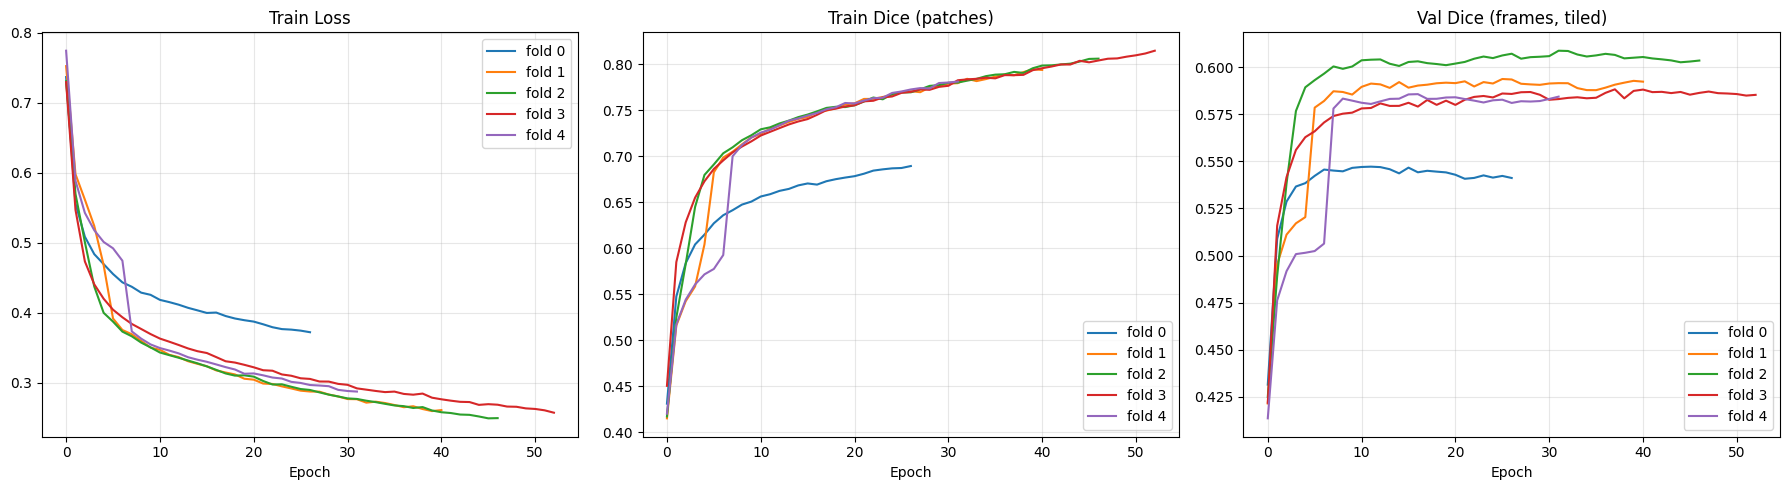

In [35]:
# =============================================================================
# Training Curves (all folds)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for f, h in enumerate(fold_histories):

    axes[0].plot(h["train_loss"], label=f"fold {f}")
    axes[1].plot(h["train_dice"], label=f"fold {f}")
    axes[2].plot(h["val_dice"], label=f"fold {f}")

for ax, title in zip(axes, ["Train Loss", "Train Dice (patches)",
                            "Val Dice (frames, tiled)"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [36]:
# =============================================================================
# Held-Out Test Evaluation
# =============================================================================
#
# Run this ONCE, at the end, after every configuration decision is frozen.
# Re-running it while tuning turns the held-out set into a validation set.
#
# Each fold model is scored separately on the same 8 frames, so the spread
# reported here is model-to-model variance, not an error bar on the test set
# itself. With 8 frames the test estimate stays coarse; the cross-validation
# number above remains the primary result.

test_results = []

for fold in range(N_FOLDS):

    ckpt = torch.load(fold_checkpoint(fold), map_location=DEVICE)

    model = build_model()

    _ref = model.state_dict()

    model.load_state_dict(
        {k: v.to(dtype=_ref[k].dtype) for k, v in ckpt["ema_state_dict"].items()}
    )

    res = evaluate_frames(model, TEST_STEMS, desc=f"test fold {fold}")

    test_results.append(res)

    print(f"fold {fold}: dice {res['dice']:.4f}  iou {res['iou']:.4f}")

summarise(test_results,
          f"HELD-OUT TEST ({len(TEST_STEMS)} frames, per-fold models)")

fold 0: dice 0.5443  iou 0.3997


fold 1: dice 0.5808  iou 0.4257


fold 2: dice 0.5806  iou 0.4272


fold 3: dice 0.5845  iou 0.4282


fold 4: dice 0.5827  iou 0.4266
HELD-OUT TEST (8 frames, per-fold models)
Dice        0.5746 +/- 0.0152   folds: [0.5443, 0.5808, 0.5806, 0.5845, 0.5827]
IoU         0.4215 +/- 0.0109
Accuracy    0.9747 +/- 0.0003
--------------------------------------------------------------
Per-class F1
  Background  0.9881 +/- 0.0001
  Artery      0.6514 +/- 0.0037
  Overlap     0.3539 +/- 0.0479
  Vein        0.7184 +/- 0.0039
--------------------------------------------------------------
Significance threshold: a change must exceed 2.0 x 0.0152 = 0.0305 Dice to be real.


{'dice_mean': 0.5745907001197338, 'dice_std': 0.015226957205487356}

---

# Test-Time Augmentation (TTA)

TTA is scored through the **same tiled path as validation**.

## Why this changed

Earlier revisions pushed whole 768x768 frames through the network in a single
forward pass. Once validation moved to tiled inference, that made the TTA
numbers incomparable with the fold numbers: they measured a different input
distribution, not a different amount of averaging. Every TTA view is now
tiled internally, so the only difference between the baseline and a TTA
variant is the averaging itself.

## Strategy

**Transform group: D4 (dihedral) x multi-scale**

The 8 elements of `D4` are applied to every input:

| k | Transform |
|---|-----------|
| 0 | identity |
| 1 | rot 90 |
| 2 | rot 180 |
| 3 | rot 270 |
| 4 | hflip |
| 5 | hflip + rot 90 |
| 6 | hflip + rot 180 |
| 7 | hflip + rot 270 |

Flips and 90-degree rotations are **lossless** memory permutations, so they
introduce no resampling error. Each is additionally evaluated at 3 scales
(0.75x, 1.0x, 1.25x), giving 24 views per frame. On non-square input the
shape-preserving subgroup {identity, rot180, hflip, vflip} is used instead.

**Cost.** Tiling multiplies the pass count. A 768 frame at a 256 tile with
stride 128 is 25 tiles, so 24 views cost 600 tile forward passes per frame.
Budget for it, or reduce `TTA_SCALES` first — the 0.75x downscale has the worst
measured round-trip error of any transform in the set.

**Elastic variants**

Optional, `TTA_ELASTIC_N` fields per view, raising the count to 72 views. A TTA
transform must be invertible: warp, predict, unwarp, average. D4 inverts
exactly; elastic does not. Given a forward displacement field `d`, the inverse
must satisfy a fixed-point condition with no closed form, so a residual warp of
one to two pixels remains — the same scale as the structures being segmented.
Elastic is expected to score *worse* than plain D4 and is reported as its own
variant so a bad result cannot contaminate the D4 numbers.

**Merging**

1. `tta_prob` — mean of post-softmax probabilities, then argmax. Well
   calibrated; one overconfident view cannot dominate.
2. `tta_logit` — mean of raw logits. Sharper boundaries, more outlier
   sensitive.

Both are compared against `baseline` (no augmentation, same tiling) on the same
frames.

## Interpreting the result

**The test set is small.** The comparison cell reports the fold-to-fold spread
and prints an explicit threshold. Any difference that does not clear
`SIGNIFICANCE_SIGMA` times that spread is labelled *within noise* and should be
reported as no measurable difference, not as an improvement.

**The training set already contains the D4 group.** Flips and 90-degree
rotations are part of the offline augmentation set, so the network is close to
D4-invariant before TTA is applied. Averaging over symmetries the model has
effectively memorised adds little information. A small or null gain is the
expected outcome, not an anomaly.

---

In [37]:
# =============================================================================
# Test-Time Augmentation Configuration
# =============================================================================

# Dihedral group D4 -- 8 lossless symmetries (no interpolation error)
#   k = 0..3  ->  rot90 applied k times
#   k = 4..7  ->  horizontal flip, then rot90 applied (k - 4) times
TTA_D4_KS = [0, 1, 2, 3, 4, 5, 6, 7]

# Multi-scale factors, applied on top of every D4 transform
TTA_SCALES = [0.75, 1.0, 1.25]

# Encoder has 4 max-pools, so spatial dims must stay divisible by 16
TTA_SIZE_MULTIPLE = 16

# ---------------------------------------------------------------------------
# Elastic deformation
# ---------------------------------------------------------------------------
#
# Unlike D4, elastic warping has NO exact inverse. The inverse displacement
# field must be solved numerically, so every elastic view costs two bilinear
# resamplings plus a residual inversion error.
#
# Measured round-trip error on a 1px line pattern (signal mass 0.121):
#     D4 rot90      0.00000   exact
#     scale 1.25    0.06134   already in the pipeline
#     elastic a=12  0.07715   this transform
#     scale 0.75    0.10045   already in the pipeline (worst)
#
# Elastic is therefore no more destructive than the multi-scale transforms
# already in use -- but it is not free, and it is reported as its OWN variant
# so a bad result cannot contaminate the working D4+scale numbers.

TTA_ELASTIC_N = 2            # random fields per (scale, D4) combination
TTA_ELASTIC_ALPHA = 12.0     # peak displacement, pixels
TTA_ELASTIC_SIGMA = 12.0     # field smoothness, pixels (low = crumpled)
TTA_ELASTIC_INV_ITERS = 6    # fixed-point iterations; 1 == naive -d shortcut
TTA_ELASTIC_SEED = 1234      # fields are regenerated identically every run

TTA_NUM_PASSES = len(TTA_D4_KS) * len(TTA_SCALES)

TTA_ELASTIC_PASSES = TTA_NUM_PASSES * (1 + TTA_ELASTIC_N)

print("=" * 60)
print(f"D4 transforms            : {len(TTA_D4_KS)}")
print(f"Scales                   : {TTA_SCALES}")
print(f"Forward passes per image : {TTA_NUM_PASSES}")
print(f"Elastic fields per view  : {TTA_ELASTIC_N} (alpha={TTA_ELASTIC_ALPHA}, sigma={TTA_ELASTIC_SIGMA})")
print(f"Passes with elastic      : {TTA_ELASTIC_PASSES}")
print(f"Merge strategies         : mean-softmax, mean-logits")
print("=" * 60)

D4 transforms            : 8
Scales                   : [0.75, 1.0, 1.25]
Forward passes per image : 24
Elastic fields per view  : 2 (alpha=12.0, sigma=12.0)
Passes with elastic      : 72
Merge strategies         : mean-softmax, mean-logits


In [38]:
# =============================================================================
# Dihedral Group (D4) Transforms
# =============================================================================

def d4_forward(x, k):
    """
    Apply the k-th element of the dihedral group D4 to an NCHW tensor.

    k = 0..3 -> rot90 k times
    k = 4..7 -> horizontal flip, then rot90 (k - 4) times

    Flips and 90-degree rotations are exact memory permutations, so this
    introduces no interpolation error.
    """

    if k >= 4:
        x = torch.flip(x, dims=[3])

    r = k % 4

    if r:
        x = torch.rot90(x, r, dims=[2, 3])

    return x


def d4_inverse(x, k):
    """
    Undo d4_forward.

    forward is  rot^r . flip   (flip applied first), so the inverse is
    (rot^r . flip)^-1 = flip^-1 . rot^-r = flip . rot^-r
    """

    r = k % 4

    if r:
        x = torch.rot90(x, -r, dims=[2, 3])

    if k >= 4:
        x = torch.flip(x, dims=[3])

    return x


def _round_to_multiple(value, multiple=TTA_SIZE_MULTIPLE):
    """
    Round a spatial dimension to the nearest valid multiple for the encoder.
    """

    return max(multiple, int(round(value / multiple)) * multiple)


# ---------------------------------------------------------------------------
# Sanity check: every transform must round-trip exactly
# ---------------------------------------------------------------------------

_probe = torch.randn(2, 3, 64, 64)

for _k in TTA_D4_KS:

    _restored = d4_inverse(d4_forward(_probe, _k), _k)

    assert torch.equal(_probe, _restored), f"D4 round-trip failed for k={_k}"

# The 8 transforms must be distinct, otherwise TTA is averaging duplicates
_signatures = {
    d4_forward(_probe, _k).flatten()[:512].numpy().tobytes()
    for _k in TTA_D4_KS
}

assert len(_signatures) == len(TTA_D4_KS), "D4 transforms are not distinct"

del _probe, _signatures

print("D4 transforms verified: 8 distinct, all round-trip exactly.")

D4 transforms verified: 8 distinct, all round-trip exactly.


In [39]:
# =============================================================================
# Elastic Deformation for TTA
# =============================================================================
#
# A TTA transform must be invertible: warp the input, predict, unwarp the
# logits, average. D4 inverts exactly. Elastic does not -- given a forward
# displacement field d, the inverse field d_inv must satisfy
#
#     d_inv(x) = -d(x + d_inv(x))
#
# which has no closed form. It is solved below by fixed-point iteration, the
# standard approach in deformable registration.


def _gaussian_kernel1d(sigma, device, dtype):

    radius = max(1, int(3.0 * sigma))

    x = torch.arange(-radius, radius + 1, device=device, dtype=dtype)

    k = torch.exp(-(x ** 2) / (2.0 * sigma ** 2))

    return k / k.sum()


def _smooth(field, sigma):
    """Separable Gaussian blur of an (N, 2, H, W) displacement field."""

    k = _gaussian_kernel1d(sigma, field.device, field.dtype)

    r = (k.numel() - 1) // 2
    c = field.shape[1]

    kx = k.view(1, 1, 1, -1).expand(c, 1, 1, -1)
    ky = k.view(1, 1, -1, 1).expand(c, 1, -1, 1)

    field = F.conv2d(F.pad(field, (r, r, 0, 0), mode="replicate"), kx, groups=c)
    field = F.conv2d(F.pad(field, (0, 0, r, r), mode="replicate"), ky, groups=c)

    return field


def _base_grid(n, h, w, device, dtype):
    """Identity sampling grid in align_corners=False convention."""

    ys = (torch.arange(h, device=device, dtype=dtype) + 0.5) / h * 2.0 - 1.0
    xs = (torch.arange(w, device=device, dtype=dtype) + 0.5) / w * 2.0 - 1.0

    gy, gx = torch.meshgrid(ys, xs, indexing="ij")

    return torch.stack([gx, gy], dim=-1).unsqueeze(0).expand(n, -1, -1, -1)


def make_elastic_field(n, h, w, device, generator,
                       alpha=None, sigma=None, dtype=torch.float32):
    """
    Smooth random displacement field, returned in NORMALISED grid units
    (the convention grid_sample expects), peak magnitude alpha pixels.
    """

    alpha = TTA_ELASTIC_ALPHA if alpha is None else alpha
    sigma = TTA_ELASTIC_SIGMA if sigma is None else sigma

    d = torch.randn(n, 2, h, w, device=device, dtype=dtype,
                    generator=generator)

    d = _smooth(d, sigma)

    # Normalise so the largest displacement is exactly alpha pixels,
    # otherwise the amplitude drifts with sigma and image size.
    peak = d.flatten(1).abs().amax(dim=1).clamp_min(1e-8)
    d = d / peak.view(n, 1, 1, 1) * alpha

    d_norm = torch.empty_like(d)
    d_norm[:, 0] = d[:, 0] * (2.0 / w)    # x channel
    d_norm[:, 1] = d[:, 1] * (2.0 / h)    # y channel

    return d_norm


def invert_elastic_field(d_norm, iters=None):
    """
    Fixed-point inversion. Set iters=1 to recover the common -d shortcut.
    Residual at alpha=12, sigma=12 on 256px: ~0.66px at 6 iters,
    ~0.23px at 10.
    """

    iters = TTA_ELASTIC_INV_ITERS if iters is None else iters

    n, _, h, w = d_norm.shape

    bg = _base_grid(n, h, w, d_norm.device, d_norm.dtype)

    inv = torch.zeros_like(d_norm)

    for _ in range(iters):

        g = bg + inv.permute(0, 2, 3, 1)

        inv = -F.grid_sample(
            d_norm, g,
            mode="bilinear",
            padding_mode="border",
            align_corners=False
        )

    return inv


def elastic_warp(x, d_norm):
    """
    Apply a displacement field to an (N, C, H, W) tensor.

    padding_mode="border" rather than "zeros": zero-padding would inject
    spurious background evidence at the frame edge, which then gets averaged
    into the TTA result as a confident background vote.
    """

    n, _, h, w = x.shape

    bg = _base_grid(n, h, w, x.device, x.dtype)

    g = bg + d_norm.permute(0, 2, 3, 1).to(x.dtype)

    return F.grid_sample(
        x, g,
        mode="bilinear",
        padding_mode="border",
        align_corners=False
    )


# ---------------------------------------------------------------------------
# Sanity check: quantify what the round trip costs on thin structures
# ---------------------------------------------------------------------------

_h = _w = 256

_probe = torch.zeros(1, 1, _h, _w)
_probe[:, :, ::17, :] = 1.0        # 1px lines: worst case for resampling
_probe[:, :, :, ::17] = 1.0

_gen = torch.Generator().manual_seed(TTA_ELASTIC_SEED)
_d = make_elastic_field(1, _h, _w, _probe.device, _gen)

_rt = elastic_warp(elastic_warp(_probe, _d), invert_elastic_field(_d))

_err_elastic = (_rt - _probe).abs().mean().item()

_err_d4 = (
    torch.rot90(torch.rot90(_probe, 1, [2, 3]), -1, [2, 3]) - _probe
).abs().mean().item()

print(f"Probe signal mass          : {_probe.mean().item():.4f}")
print(f"D4 round-trip error        : {_err_d4:.5f}  (exact)")
print(f"Elastic round-trip error   : {_err_elastic:.5f}")

for _s in TTA_SCALES:

    if _s == 1.0:
        continue

    _sz = (_round_to_multiple(_h * _s), _round_to_multiple(_w * _s))

    _down = F.interpolate(_probe, size=_sz, mode="bilinear",
                          align_corners=False)
    _up = F.interpolate(_down, size=(_h, _w), mode="bilinear",
                        align_corners=False)

    print(f"Scale {_s} round-trip error : "
          f"{(_up - _probe).abs().mean().item():.5f}")

assert _err_d4 == 0.0, "D4 must remain exact"

del _probe, _d, _rt


Probe signal mass          : 0.1211
D4 round-trip error        : 0.00000  (exact)
Elastic round-trip error   : 0.07715
Scale 0.75 round-trip error : 0.10045
Scale 1.25 round-trip error : 0.06134


In [40]:
# =============================================================================
# TTA Prediction (tiled)
# =============================================================================
#
# Every TTA view is now scored by the SAME tiled path as evaluate_frames.
#
# The previous version pushed whole frames through the network in one pass.
# Once validation moved to tiled inference that made the TTA numbers
# incomparable with the fold numbers -- they were measuring a different input
# distribution, not a different amount of averaging. Tiling inside each view
# removes that.
#
# Cost: TTA is now (passes x tiles) forward passes per frame instead of
# (passes). At 768 frames, 256 tiles and stride 128 that is 25 tiles, so 24
# D4 x scale views cost 600 tile passes per frame. Budget accordingly.


@torch.no_grad()
def predict_tta(model, image, d4_ks=None, scales=None, elastic_n=0,
                use_amp=True):
    # Multi-scale + dihedral test-time augmentation, tiled.
    #
    # image     : (N, C, H, W) float tensor on the target device.
    # elastic_n : elastic fields per (scale, D4) view. 0 = pure D4 x scale.
    #
    # Returns dict with "prob", "logit" (both (N, NUM_CLASSES, H, W))
    # and "passes".

    if d4_ks is None:
        d4_ks = TTA_D4_KS

    if scales is None:
        scales = TTA_SCALES

    model.eval()

    n, _, h, w = image.shape

    # 90/270-degree rotations only preserve shape on square inputs. For
    # non-square inputs fall back to the shape-preserving subgroup
    # {identity, rot180, hflip, vflip} = even k.
    ks = d4_ks if h == w else [k for k in d4_ks if k % 2 == 0]

    gen = None

    if elastic_n > 0:
        gen = torch.Generator(device=image.device)
        gen.manual_seed(TTA_ELASTIC_SEED)

    prob_sum = torch.zeros(n, NUM_CLASSES, h, w,
                           device=image.device, dtype=torch.float32)

    logit_sum = torch.zeros_like(prob_sum)

    count = 0

    for scale in scales:

        if scale == 1.0:
            scaled = image

        else:
            size = (_round_to_multiple(h * scale),
                    _round_to_multiple(w * scale))

            assert min(size) >= PATCH_SIZE, (
                f"scale {scale} shrinks the frame to {size}, smaller than the "
                f"{PATCH_SIZE} tile. Drop the scale or reduce PATCH_SIZE."
            )

            scaled = F.interpolate(image, size=size, mode="bilinear",
                                   align_corners=False)

        for k in ks:

            augmented = d4_forward(scaled, k)

            fields = [None]

            if elastic_n > 0:

                sh, sw = augmented.shape[-2:]

                for _ in range(elastic_n):
                    fields.append(
                        make_elastic_field(augmented.shape[0], sh, sw,
                                           augmented.device, gen)
                    )

            for field in fields:

                view = augmented if field is None else elastic_warp(
                    augmented, field
                )

                # Tiled, exactly as in evaluate_frames
                logits = predict_tiled(model, view, use_amp=use_amp).float()

                # Unwarp in reverse order of application:
                # elastic (approximate) -> D4 (exact) -> resize (approximate)
                if field is not None:
                    logits = elastic_warp(logits, invert_elastic_field(field))

                logits = d4_inverse(logits, k)

                if logits.shape[-2:] != (h, w):
                    logits = F.interpolate(logits, size=(h, w),
                                           mode="bilinear",
                                           align_corners=False)

                logit_sum += logits
                prob_sum += torch.softmax(logits, dim=1)

                count += 1

    return {"prob": prob_sum / count,
            "logit": logit_sum / count,
            "passes": count}


@torch.no_grad()
def evaluate_frames_tta(model, stems, elastic_n=0, merge="prob", desc="tta"):
    # Same metric path as evaluate_frames, but each frame is scored through
    # predict_tta. merge is "prob" (mean softmax) or "logit" (mean logits).

    assert merge in {"prob", "logit"}

    model.eval()

    dice_values, iou_values, acc_values = [], [], []
    prec = np.zeros(NUM_CLASSES)
    rec  = np.zeros(NUM_CLASSES)
    f1   = np.zeros(NUM_CLASSES)

    ds = FrameDataset(stems)

    for i in tqdm(range(len(ds)), desc=desc, leave=False):

        image, mask = ds[i]

        res = predict_tta(model, image.unsqueeze(0).to(DEVICE),
                          elastic_n=elastic_n)

        # dice_score/iou_score argmax over dim 1, so a probability tensor and a
        # logit tensor are both valid inputs -- argmax is invariant to softmax.
        scores = res[merge]

        target = mask.unsqueeze(0).to(DEVICE)

        d, _ = dice_score(scores, target)
        u, _ = iou_score(scores, target)
        m = classification_metrics(scores, target)

        dice_values.append(d)
        iou_values.append(u)
        acc_values.append(m["accuracy"])

        prec += m["precision"]
        rec  += m["recall"]
        f1   += m["f1"]

    n = len(ds)

    return {"dice": float(np.nanmean(dice_values)),
            "iou": float(np.nanmean(iou_values)),
            "accuracy": float(np.mean(acc_values)),
            "precision": prec / n, "recall": rec / n, "f1": f1 / n}

In [41]:
# =============================================================================
# TTA Comparison on the Held-Out Test Set
# =============================================================================
#
# Run once, after configuration is frozen.
#
# Two caveats belong with whatever this prints.
#
# 1. The test set is small. Read the fold-to-fold spread as the error bar and
#    ignore any difference that does not clear it.
#
# 2. D4 is already in the training augmentation set, so the network is close to
#    D4-invariant before TTA is applied. Averaging over symmetries the model has
#    effectively memorised adds little information. A small or null gain is the
#    expected outcome, not an anomaly.

TTA_VARIANTS = [
    ("baseline",   None),
    ("tta_prob",   dict(elastic_n=0, merge="prob")),
    ("tta_logit",  dict(elastic_n=0, merge="logit")),
    ("tta_elastic", dict(elastic_n=TTA_ELASTIC_N, merge="prob")),
]

tta_table = {name: [] for name, _ in TTA_VARIANTS}

for fold in range(N_FOLDS):

    ckpt = torch.load(fold_checkpoint(fold), map_location=DEVICE)

    model = build_model()

    _ref = model.state_dict()
    model.load_state_dict(
        {k: v.to(dtype=_ref[k].dtype) for k, v in ckpt["ema_state_dict"].items()}
    )

    for name, kwargs in TTA_VARIANTS:

        if kwargs is None:
            res = evaluate_frames(model, TEST_STEMS, desc=f"{name} f{fold}")
        else:
            res = evaluate_frames_tta(model, TEST_STEMS,
                                      desc=f"{name} f{fold}", **kwargs)

        tta_table[name].append(res)

    print(f"fold {fold}: " + "  ".join(
        f"{n}={tta_table[n][-1]['dice']:.4f}" for n, _ in TTA_VARIANTS
    ))

print()
print("=" * 62)
print("TTA COMPARISON (held-out test, mean +/- std across fold models)")
print("=" * 62)

_base = np.array([r["dice"] for r in tta_table["baseline"]])
_noise = _base.std()

for name, _ in TTA_VARIANTS:

    d = np.array([r["dice"] for r in tta_table[name]])
    delta = d.mean() - _base.mean()

    verdict = ""
    if name != "baseline":
        verdict = ("REAL" if abs(delta) > SIGNIFICANCE_SIGMA * _noise
                   else "within noise")

    print(f"{name:<14}{d.mean():.4f} +/- {d.std():.4f}"
          f"   delta {delta:+.4f}   {verdict}")

print("-" * 62)
print(f"Threshold: |delta| must exceed {SIGNIFICANCE_SIGMA} x {_noise:.4f} = "
      f"{SIGNIFICANCE_SIGMA * _noise:.4f}")
print("=" * 62)

fold 0: baseline=0.5443  tta_prob=0.5155  tta_logit=0.5003  tta_elastic=0.4997


fold 1: baseline=0.5808  tta_prob=0.5901  tta_logit=0.5941  tta_elastic=0.5870


fold 2: baseline=0.5806  tta_prob=0.5879  tta_logit=0.5897  tta_elastic=0.5851


fold 3: baseline=0.5845  tta_prob=0.5882  tta_logit=0.5888  tta_elastic=0.5829


fold 4: baseline=0.5827  tta_prob=0.5964  tta_logit=0.5977  tta_elastic=0.5939

TTA COMPARISON (held-out test, mean +/- std across fold models)
baseline      0.5746 +/- 0.0152   delta +0.0000   
tta_prob      0.5756 +/- 0.0302   delta +0.0010   within noise
tta_logit     0.5741 +/- 0.0371   delta -0.0005   within noise
tta_elastic   0.5697 +/- 0.0352   delta -0.0049   within noise
--------------------------------------------------------------
Threshold: |delta| must exceed 2.0 x 0.0152 = 0.0305


fold 0 | epoch 11 | val dice 0.5472


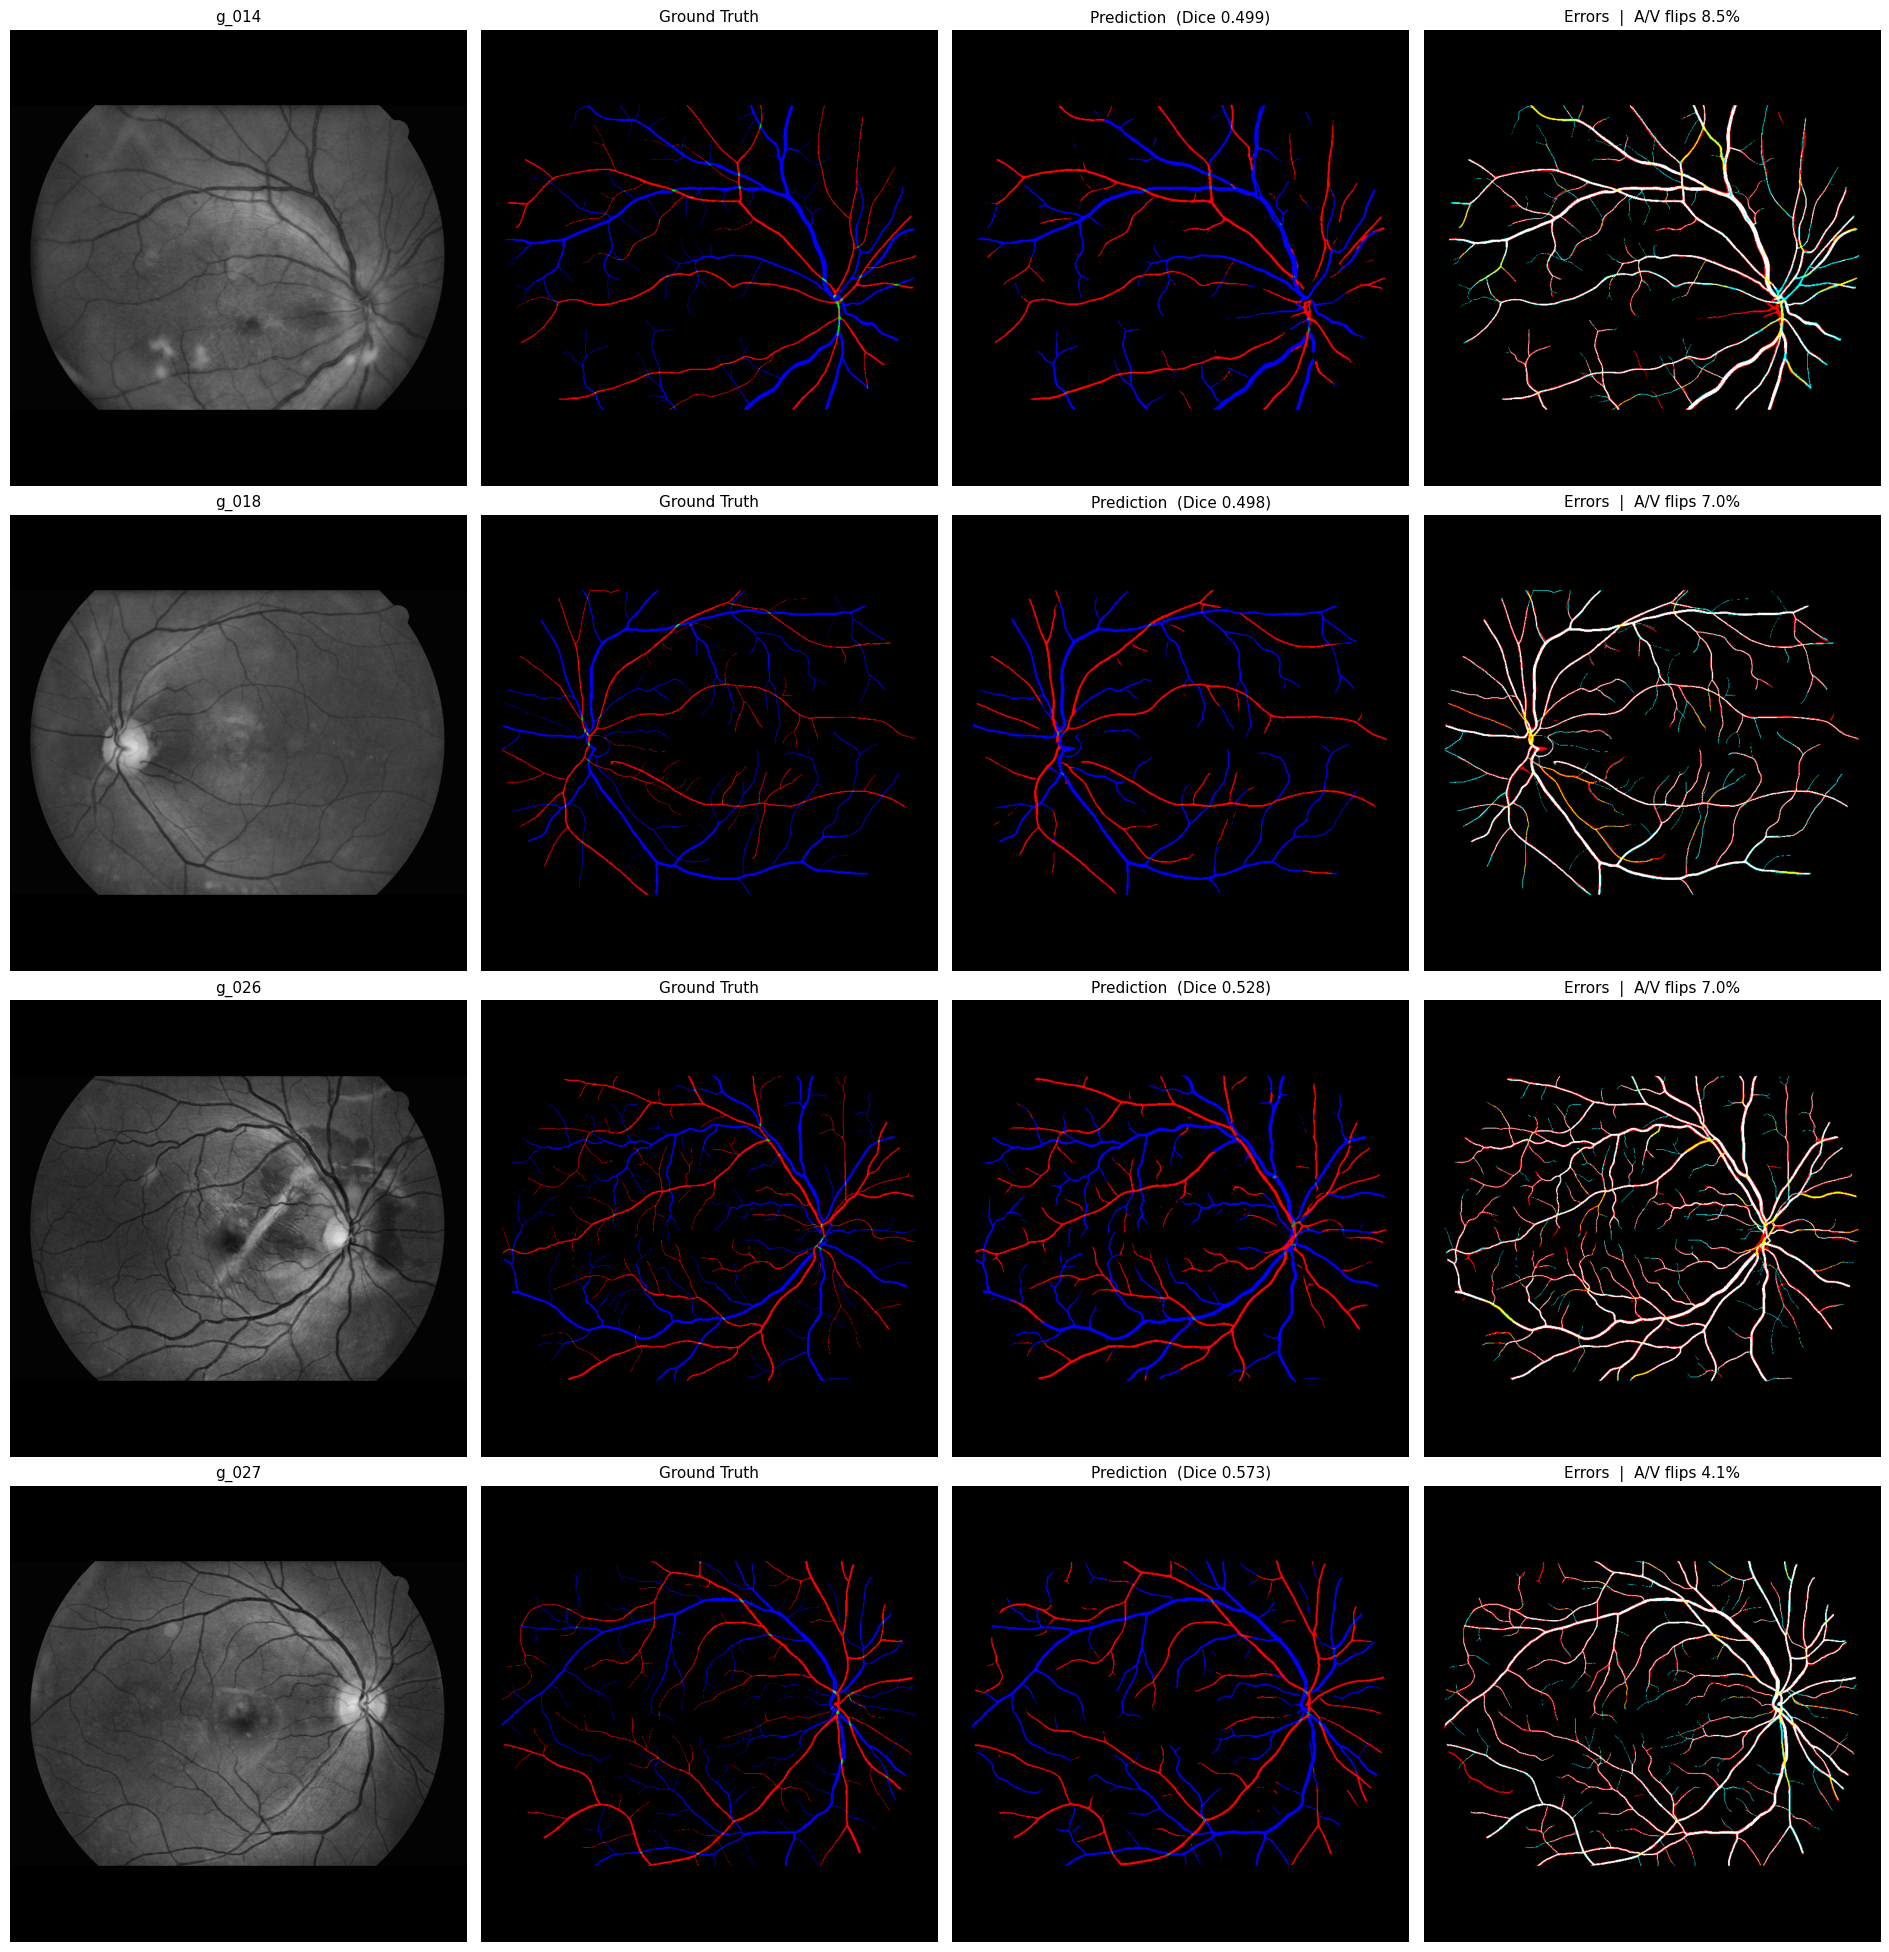

In [45]:
# =============================================================================
# Qualitative Visualisation -- Held-Out Test Frames
# =============================================================================
#
# Input | Ground Truth | Prediction | Error map
#
# Error map colours:
#   white   correct vessel pixel
#   yellow  A/V label flip        (vessel found, identity wrong)
#   red     false positive        (predicted vessel, none there)
#   cyan    false negative        (missed a vessel)

VIS_FOLD = 0
VIS_N = 4


def load_fold_model(fold):

    ckpt = torch.load(fold_checkpoint(fold), map_location=DEVICE)

    model = build_model()

    _ref = model.state_dict()
    model.load_state_dict(
        {k: v.to(dtype=_ref[k].dtype) for k, v in ckpt["ema_state_dict"].items()}
    )

    model.eval()

    return model, ckpt


def error_map(pred, gt):

    h, w = gt.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)

    pred_v = pred > 0
    gt_v   = gt > 0

    out[pred_v & gt_v & (pred == gt)] = [255, 255, 255]   # correct
    out[pred_v & gt_v & (pred != gt)] = [255, 255,   0]   # label flip
    out[pred_v & ~gt_v]               = [255,   0,   0]   # false positive
    out[~pred_v & gt_v]               = [  0, 255, 255]   # false negative

    return out


model, ckpt = load_fold_model(VIS_FOLD)

print(f"fold {VIS_FOLD} | epoch {ckpt['epoch']} | val dice {ckpt['val_dice']:.4f}")

stems = TEST_STEMS[:VIS_N]
ds = FrameDataset(stems)

fig, axes = plt.subplots(len(stems), 4, figsize=(19, 4.9 * len(stems)))

if len(stems) == 1:
    axes = axes[None, :]

for r, stem in enumerate(stems):

    image, mask = ds[r]

    logits = predict_frame(model, image)
    pred = torch.argmax(logits, dim=0).cpu().numpy().astype(np.uint8)

    d, per_class = dice_score(logits.unsqueeze(0), mask.unsqueeze(0).to(DEVICE))

    gt = mask.numpy().astype(np.uint8)
    img = np.transpose(image.numpy(), (1, 2, 0))

    flips = int(((pred > 0) & (gt > 0) & (pred != gt)).sum())
    vessel = int((gt > 0).sum())

    panels = [
        (img, f"{stem}"),
        (class_to_rgb(gt), "Ground Truth"),
        (class_to_rgb(pred), f"Prediction  (Dice {d:.3f})"),
        (error_map(pred, gt), f"Errors  |  A/V flips {flips / max(vessel, 1) * 100:.1f}%"),
    ]

    for c, (im, title) in enumerate(panels):
        axes[r, c].imshow(im)
        axes[r, c].set_title(title, fontsize=11)
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_13572\3143197626.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


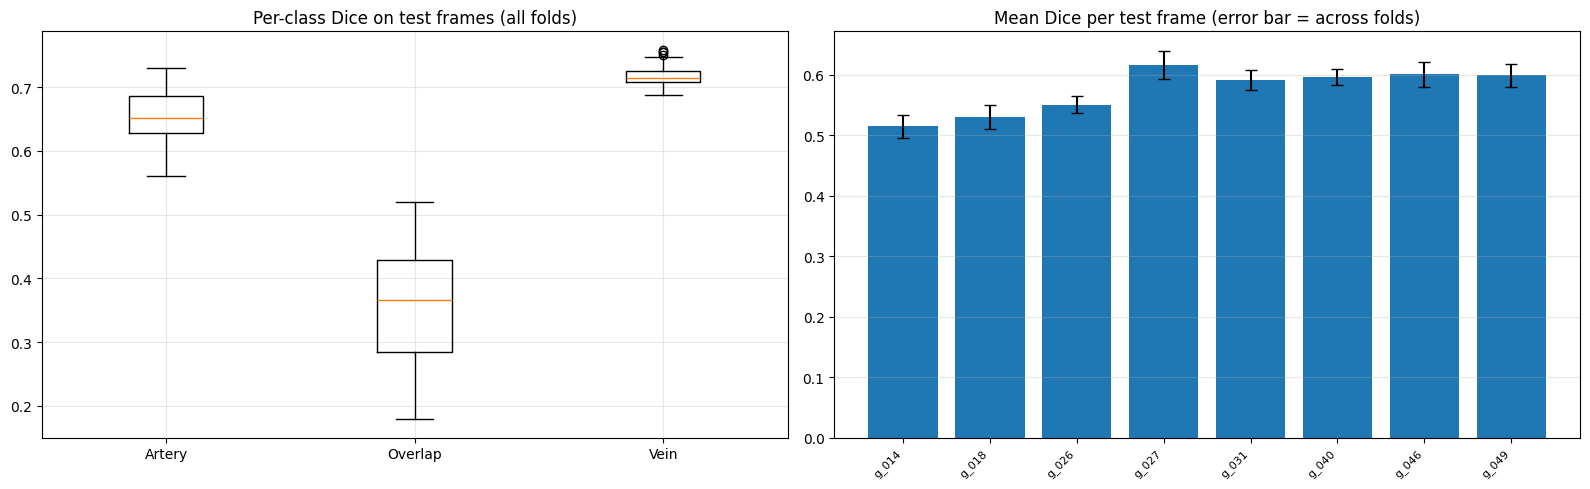

In [46]:
# =============================================================================
# Per-Class Dice, Every Fold, Every Test Frame
# =============================================================================

rows = []

for fold in range(N_FOLDS):

    model, _ = load_fold_model(fold)
    ds = FrameDataset(TEST_STEMS)

    for i, stem in enumerate(TEST_STEMS):

        image, mask = ds[i]

        logits = predict_frame(model, image)
        _, per_class = dice_score(logits.unsqueeze(0), mask.unsqueeze(0).to(DEVICE))

        rows.append([fold, stem] + list(per_class))

per_class_arr = np.array([r[2:] for r in rows], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# spread across folds, per class
axes[0].boxplot(
    [per_class_arr[:, i] for i in range(per_class_arr.shape[1])],
    labels=CLASS_NAMES[1:]
)
axes[0].set_title("Per-class Dice on test frames (all folds)")
axes[0].grid(True, alpha=0.3)

# per-frame mean, grouped by frame
frame_means = {}
for (fold, stem), v in zip([(r[0], r[1]) for r in rows], per_class_arr):
    frame_means.setdefault(stem, []).append(np.nanmean(v))

axes[1].bar(
    range(len(frame_means)),
    [np.mean(v) for v in frame_means.values()],
    yerr=[np.std(v) for v in frame_means.values()],
    capsize=4
)
axes[1].set_xticks(range(len(frame_means)))
axes[1].set_xticklabels(list(frame_means), rotation=45, ha="right", fontsize=8)
axes[1].set_title("Mean Dice per test frame (error bar = across folds)")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

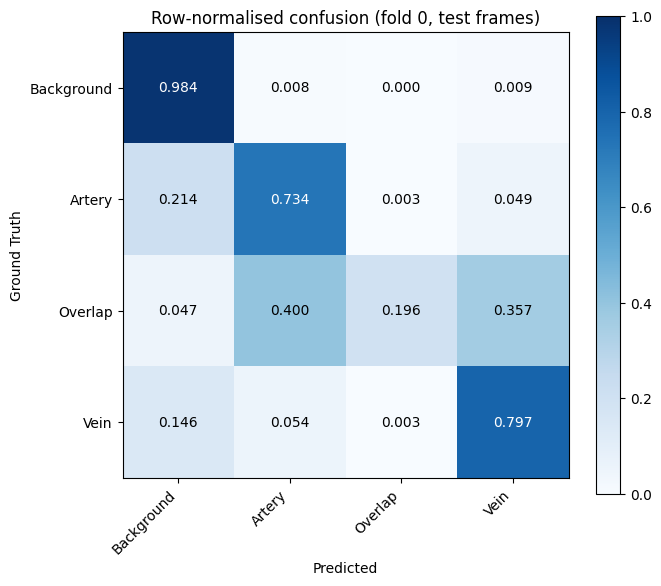

In [47]:
# =============================================================================
# Confusion Matrix -- Pooled Over Test Frames
# =============================================================================

from sklearn.metrics import confusion_matrix

model, _ = load_fold_model(VIS_FOLD)
ds = FrameDataset(TEST_STEMS)

all_pred, all_gt = [], []

for i in range(len(ds)):

    image, mask = ds[i]

    logits = predict_frame(model, image)
    pred = torch.argmax(logits, dim=0).cpu().numpy()

    all_pred.append(pred.ravel())
    all_gt.append(mask.numpy().ravel())

cm = confusion_matrix(
    np.concatenate(all_gt),
    np.concatenate(all_pred),
    labels=[0, 1, 2, 3]
)

cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(4)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(4)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("Ground Truth")
ax.set_title(f"Row-normalised confusion (fold {VIS_FOLD}, test frames)")

for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cm_norm[i, j]:.3f}", ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=10)

fig.colorbar(im)
plt.tight_layout()
plt.show()

In [49]:
# =============================================================================
# Corrected diagnostic: where does the false-positive mass actually sit?
# =============================================================================

from skimage.morphology import skeletonize, binary_dilation, disk

model, _ = load_fold_model(VIS_FOLD)
ds = FrameDataset(TEST_STEMS)

halo_all, spur_all, fn_all, ceil_all, cld_all = [], [], [], [], []

for i, stem in enumerate(TEST_STEMS):

    image, mask = ds[i]

    pred = torch.argmax(predict_frame(model, image), dim=0).cpu().numpy()
    gt = mask.numpy()

    P, G = pred > 0, gt > 0

    # halo = false positive touching a true vessel (thickness)
    # spurious = false positive nowhere near one (hallucination)
    G_dil = binary_dilation(G, disk(2))

    fp = P & ~G
    halo = (fp & G_dil).sum()
    spur = (fp & ~G_dil).sum()
    fn = (~P & G).sum()
    inter = (P & G).sum()

    # Dice if all halo were removed, spurious and misses untouched
    P_thin = inter + spur
    ceiling = 2 * inter / max(P_thin + G.sum(), 1)

    # clDice: tolerant topology score (skeleton inside the other's mask)
    Sp, Sg = skeletonize(P), skeletonize(G)
    tprec = (Sp & G).sum() / max(Sp.sum(), 1)
    tsens = (Sg & P).sum() / max(Sg.sum(), 1)
    cld = 2 * tprec * tsens / max(tprec + tsens, 1e-9)

    halo_all.append(halo / G.sum())
    spur_all.append(spur / G.sum())
    fn_all.append(fn / G.sum())
    ceil_all.append(ceiling)
    cld_all.append(cld)

    print(f"{stem}: halo {halo/G.sum():.3f} | spurious {spur/G.sum():.3f} | "
          f"missed {fn/G.sum():.3f} | ceiling {ceiling:.3f} | clDice {cld:.3f}")

print()
print(f"mean halo FP      (thickness)   : {np.mean(halo_all):.3f}  of true vessel area")
print(f"mean spurious FP  (hallucinated): {np.mean(spur_all):.3f}")
print(f"mean missed       (thin vessels): {np.mean(fn_all):.3f}")
print(f"mean Dice if halo removed       : {np.mean(ceil_all):.3f}  (currently 0.745)")
print(f"mean clDice (tolerant topology) : {np.mean(cld_all):.3f}")
print()
print("halo >> spurious  -> thinning fixes it, alpha/beta is the lever")
print("clDice > 0.85     -> the vessel tree is correct, only widths are wrong")

g_014: halo 0.295 | spurious 0.032 | missed 0.208 | ceiling 0.868 | clDice 0.763
g_018: halo 0.386 | spurious 0.020 | missed 0.193 | ceiling 0.883 | clDice 0.758
g_026: halo 0.466 | spurious 0.022 | missed 0.116 | ceiling 0.928 | clDice 0.794
g_027: halo 0.416 | spurious 0.023 | missed 0.146 | ceiling 0.910 | clDice 0.788
g_031: halo 0.288 | spurious 0.004 | missed 0.210 | ceiling 0.881 | clDice 0.748
g_040: halo 0.279 | spurious 0.005 | missed 0.195 | ceiling 0.889 | clDice 0.802
g_046: halo 0.433 | spurious 0.012 | missed 0.130 | ceiling 0.925 | clDice 0.793
g_049: halo 0.382 | spurious 0.041 | missed 0.208 | ceiling 0.865 | clDice 0.719

mean halo FP      (thickness)   : 0.368  of true vessel area
mean spurious FP  (hallucinated): 0.020
mean missed       (thin vessels): 0.176
mean Dice if halo removed       : 0.894  (currently 0.745)
mean clDice (tolerant topology) : 0.771

halo >> spurious  -> thinning fixes it, alpha/beta is the lever
clDice > 0.85     -> the vessel tree is correc